# 🐶 Classification of Malignant Melanoma in Canines (CATCH) — **Full Code Notebook**
### Weeks 1–6 · Segmentation & Classification · Project DAIM2025A_088

**Student:** Muhammad Tayyab Abbas &nbsp;·&nbsp; **Supervisor:** Dr Claire Cashmore &nbsp;·&nbsp; University of Hull

This is the **self-contained** project notebook: **every module of the project's
source code is defined inline here** (no hidden `src/` imports), followed by the
real CATCH data, a live preprocessing demo, and the results. Run the cells top to
bottom and the whole project is defined and exercised inside this one file.

**Contents**
1. Setup & configuration (inline)
2. **The full source code**, module by module (preprocessing → models → training)
3. Real CATCH dataset — folder & annotations
4. Live preprocessing demo (Weeks 1–2)
5. Segmentation & classification results (Weeks 3–6)
6. How to run on the full real dataset

## 0. Plan — segmentation → classification (the supervisor's questions)

```
Whole-slide image → 256×256 patches (5×/10×/20×)
   → [U-Net SEGMENTATION] → per-pixel tumour mask
       → keep tumour patches → [CNN CLASSIFICATION] → tumour SUBTYPE
```

- **Segmentation output:** a binary tumour mask per patch (`1`=tumour, `0`=rest).
- **Classification:** the tumour **subtype** — the real **7 CATCH subtypes**
  (Melanoma, Mast Cell Tumor, SCC, PNST, Trichoblastoma, Histiocytoma,
  Plasmacytoma), or binary melanoma-vs-rest.
- **Imbalance:** segmentation (tumour ≈ 9% of pixels) → BCE `pos_weight` + Dice;
  subtype imbalance → class-weighted cross-entropy, **after** segmentation.

## 1. Setup, imports & configuration

The first cell sets up the project root and all external libraries. The second
embeds the project configuration (identical to `config/config.yaml`) inline.

In [1]:
# --- external libraries used across the whole project ---
import os, sys, json, time, math, warnings, sqlite3, zipfile, urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
%matplotlib inline
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# project root = the folder that contains config/config.yaml
ROOT = Path.cwd()
while not (ROOT / "config" / "config.yaml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
print("Project root:", ROOT)
print("torch", torch.__version__, "| CUDA available:", torch.cuda.is_available())

FIG = ROOT / "outputs" / "figures"
LOGS = ROOT / "outputs" / "logs"

def show_img(path, title=None, size=(6, 6)):
    p = Path(path)
    if not p.exists():
        print("(not found — run the pipeline to create:", p.name, ")"); return
    import matplotlib.image as mpimg
    plt.figure(figsize=size); plt.imshow(mpimg.imread(str(p))); plt.axis("off")
    if title: plt.title(title)
    plt.show()

def load_json(name):
    p = LOGS / name
    return json.loads(p.read_text()) if p.exists() else None

Project root: E:\Project\canine-melanoma-catch
torch 2.12.1+cpu | CUDA available: False


In [2]:
import yaml

# The project configuration, embedded verbatim from config/config.yaml so the
# notebook is fully self-contained.
_CONFIG_YAML = r'''
# =====================================================================
# Configuration for CATCH preprocessing pipeline (Week 1-2)
# =====================================================================

project:
  name: "canine-melanoma-catch"
  seed: 42

paths:
  raw_dir: "data/raw"            # CATCH whole-slide images (.svs / .tiff)
  interim_dir: "data/interim"    # stain-normalised slides
  processed_dir: "data/processed"
  patches_dir: "data/processed/patches"
  figures_dir: "outputs/figures"
  logs_dir: "outputs/logs"

# ---- Real CATCH dataset (Wilm et al., 2022) ----
# Pan-tumor CAnine cuTaneous Cancer Histology dataset, hosted on TCIA.
#   350 WSIs (.svs, Aperio pyramidal) = 50 each of 7 tumour subtypes,
#   with 12,424 polygon annotations (MS-COCO JSON + SQLite3).
# DOI: 10.7937/TCIA.2M93-FX66   Reference: Sci Data 9, 588 (2022).
catch:
  doi: "10.7937/TCIA.2M93-FX66"
  tcia_collection_url: "https://www.cancerimagingarchive.net/collection/catch/"
  n_slides: 350
  slides_per_subtype: 50
  # The 7 tumour subtypes EXACTLY as named in the real CATCH annotation files
  # (verified against CATCH.json categories / CATCH.sqlite Classes).
  subtypes:
    - "Melanoma"
    - "Mast Cell Tumor"
    - "SCC"
    - "PNST"
    - "Trichoblastoma"
    - "Histiocytoma"
    - "Plasmacytoma"
  # Real CATCH slides are named by a subtype prefix, e.g. "MCT_15_1.svs".
  # Maps the filename prefix -> the canonical subtype label above.
  filename_prefix_map:
    Melanoma: "Melanoma"
    MCT: "Mast Cell Tumor"
    SCC: "SCC"
    PNST: "PNST"
    Trichoblastoma: "Trichoblastoma"
    Histiocytoma: "Histiocytoma"
    Plasmacytoma: "Plasmacytoma"
  # Whole-slide reading: CATCH .svs expose 3 levels (0.25 / 1 / 4 um/px ~ 40x/10x/2.5x).
  # We read at this objective magnification for patching (20x ~ 0.5 um/px is standard).
  wsi_read_magnification: 20
  wsi_base_magnification: 40     # CATCH scan magnification (level 0 = 0.25 um/px)
  # Annotation files (as distributed); the loader auto-discovers these names.
  coco_annotation_glob: ["CATCH.json", "*.json", "annotations*.json"]
  sqlite_annotation_glob: ["CATCH.sqlite", "*.sqlite", "*.sqlite3", "*.db"]
  # COCO/SQLite class names that count as TUMOUR (foreground) for binary
  # segmentation. Everything else (Dermis, Epidermis, Subcutis, Inflamm/Necrosis,
  # Bone, Cartilage) is non-tumour (0).
  tumour_annotation_classes:
    - "Melanoma"
    - "Mast Cell Tumor"
    - "SCC"
    - "PNST"
    - "Trichoblastoma"
    - "Histiocytoma"
    - "Plasmacytoma"

# ---- Quality assessment thresholds (quality_check.py) ----
quality:
  min_width: 256
  min_height: 256
  blur_laplacian_min: 50.0       # below this = too blurry -> flag
  min_tissue_fraction: 0.10      # at least 10% tissue or slide is flagged
  brightness_low: 25             # near-black slide
  brightness_high: 245           # washed-out / blank slide

# ---- Macenko stain normalisation (stain_normalization.py) ----
stain_normalization:
  io: 240                        # transmitted light intensity
  alpha: 1                       # percentile for robust angle estimation
  beta: 0.15                     # OD threshold to drop transparent pixels

# ---- Patch extraction (patch_extraction.py) ----
patches:
  patch_size: 256                # pixels (square)
  stride: 256                    # 256 = non-overlapping tiles
  magnifications: [5, 10, 20]    # documented target magnifications
  min_tissue_fraction: 0.50      # keep patch only if >=50% tissue
  max_patches_per_slide: 2000

# ---- Dataset split (dataset_split.py) ----
split:
  train: 0.70
  val: 0.15
  test: 0.15
  stratify: true                 # preserve class distribution

# ---- Multi-magnification patch extraction (patch_extraction.py) ----
# Proposal section 3.1.1: patches at multiple magnification levels.
# base_magnification = the magnification of the source slide (20x for CATCH 0.25 um/px).
# Lower magnifications are produced by downsampling (factor = base / target).
magnification:
  base: 20                       # source slide magnification
  levels: [5, 10, 20]            # target magnifications to extract

# ---- Data augmentation (data/augmentation.py) ----
# Proposal section 3.1.1: rotation, flips, elastic deformation, colour jitter.
augmentation:
  enabled: true
  horizontal_flip: 0.5
  vertical_flip: 0.5
  rotate90: 0.5
  elastic_deform: 0.25
  brightness_contrast: 0.3
  hue_saturation: 0.3            # colour jitter (H&E stain variation)
  gauss_noise: 0.2

# ---- U-Net segmentation (models/unet.py, training/trainer.py) ----
# Proposal section 3.1.2: U-Net + ResNet-34 encoder, BCE+Dice loss, Adam lr=1e-4,
# cosine annealing. Section 3.1.4: Dice/IoU/pixel-acc/Hausdorff evaluation.
segmentation:
  arch: "unet"                   # "unet" (smp + encoder) or "baseline" (from scratch)
  encoder: "resnet34"            # ImageNet-pretrained encoder
  encoder_weights: "imagenet"    # falls back to None (random) if offline
  in_channels: 3
  classes: 1                     # binary tumour vs background
  patch_size: 256

  # ---- training ----
  epochs: 40
  batch_size: 8
  lr: 0.0001                     # 1e-4 (proposal)
  weight_decay: 0.0001
  scheduler: "cosine"            # cosine annealing
  loss: "bce_dice"               # composite BCE + Dice
  bce_weight: 0.5
  dice_weight: 0.5
  early_stopping_patience: 10
  num_workers: 0                 # 0 is safe on Windows
  device: "auto"                 # "auto" -> cuda if available else cpu
  amp: true                      # mixed precision when on GPU

  # ---- split (slide-level, to prevent patch leakage between subsets) ----
  split_by_slide: true
  paths:
    seg_patches_dir: "data/processed/seg_patches"
    seg_splits_dir: "data/processed/seg_splits"
    checkpoints_dir: "outputs/checkpoints"
    tensorboard_dir: "outputs/tensorboard"

# ---- Tumour-subtype classification (Week 6+, models/classifier.py) ----
# Proposal section 3.1.3: ResNet-50 / EfficientNet-B3, ImageNet transfer learning,
# progressive unfreezing, cross-entropy with label smoothing 0.1, AdamW.
classification:
  arch: "resnet50"               # "resnet50" or "efficientnet_b3"
  pretrained: true               # ImageNet weights (falls back to random if offline)
  patch_size: 256
  # Classification mode on REAL data:
  #   "subtype"  -> full 7-class CATCH tumour-subtype classification
  #   "melanoma" -> binary Melanoma vs. non-melanoma (project focus)
  # On demo data the classes are auto-detected from the folder names instead.
  mode: "subtype"
  freeze_bn: true                # keep frozen encoder BatchNorm in eval mode
  epochs: 20
  batch_size: 16
  lr: 0.0003
  weight_decay: 0.0001
  label_smoothing: 0.1
  unfreeze_epochs: [2, 4]        # epoch thresholds to progressively unfreeze
  early_stopping_patience: 8
  num_workers: 0
  device: "auto"
  amp: true
  paths:
    cls_patches_dir: "data/processed/cls_patches"
    cls_splits_dir: "data/processed/cls_splits"

'''

PROJECT_ROOT = ROOT

def load_config():
    cfg = yaml.safe_load(_CONFIG_YAML)
    for k, v in cfg.get('paths', {}).items():
        cfg['paths'][k] = (PROJECT_ROOT / v).resolve()
    for section in ('segmentation', 'classification'):
        sub = cfg.get(section, {}).get('paths', {})
        for k, v in sub.items():
            sub[k] = (PROJECT_ROOT / v).resolve()
    return cfg

def ensure_dirs(cfg):
    for key in ('interim_dir','processed_dir','patches_dir','figures_dir','logs_dir'):
        p = cfg['paths'].get(key)
        if p is not None: Path(p).mkdir(parents=True, exist_ok=True)
    for section in ('segmentation','classification'):
        for p in cfg.get(section, {}).get('paths', {}).values():
            if p is not None: Path(p).mkdir(parents=True, exist_ok=True)

cfg = load_config(); ensure_dirs(cfg)
print('Config loaded. Real CATCH subtypes:', cfg['catch']['subtypes'])

Config loaded. Real CATCH subtypes: ['Melanoma', 'Mast Cell Tumor', 'SCC', 'PNST', 'Trichoblastoma', 'Histiocytoma', 'Plasmacytoma']


## 2. The project source code (inline)

Every module below is the **actual project code**, defined here so the notebook is
self-contained. They are ordered by dependency, so running them top-to-bottom
defines the whole library used in the rest of the notebook.

### 2.1 Utilities

#### `src/utils/seed.py` — reproducible seeding
Seeds Python/NumPy/PyTorch for reproducibility.

In [3]:
"""Reproducibility helpers.

A single place to seed Python, NumPy and (when available) PyTorch so that
training runs are repeatable — required for the cross-validation and
architecture-comparison experiments described in the proposal (section 3.1.4).
"""

import os
import random

import numpy as np


def seed_everything(seed: int = 42, deterministic: bool = True) -> int:
    """Seed all relevant RNGs. Returns the seed for convenience/logging."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    try:  # torch is optional at import time (only needed from Week 3 onward)
        import torch

        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        if deterministic:
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
    except ImportError:
        pass

    return seed

#### `src/utils/logger.py` — console+file logger
A small dual console/file logger used by the pipeline scripts.

In [4]:
"""Simple, reusable logger that writes to both console and a log file."""

import logging
from pathlib import Path


def get_logger(name: str = "catch", log_dir: str | Path | None = None) -> logging.Logger:
    logger = logging.getLogger(name)
    if logger.handlers:  # already configured
        return logger

    logger.setLevel(logging.INFO)
    fmt = logging.Formatter(
        "%(asctime)s | %(levelname)-7s | %(message)s", "%Y-%m-%d %H:%M:%S"
    )

    console = logging.StreamHandler()
    console.setFormatter(fmt)
    logger.addHandler(console)

    if log_dir is not None:
        log_dir = Path(log_dir)
        log_dir.mkdir(parents=True, exist_ok=True)
        file_handler = logging.FileHandler(log_dir / "pipeline.log", encoding="utf-8")
        file_handler.setFormatter(fmt)
        logger.addHandler(file_handler)

    return logger

### 2.2 Preprocessing

#### `src/preprocessing/image_io.py` — image / WSI loading
Loads standard images, or a WSI thumbnail via OpenSlide.

In [5]:
"""Image loading utilities.

Reads either standard images (PNG/JPG/TIFF) for development/demo, or whole-slide
images (.svs/.ndpi) via OpenSlide when available. WSIs are loaded at a downsampled
thumbnail level so they fit in memory for quality assessment and tiling.
"""

from pathlib import Path
import numpy as np
import cv2

WSI_EXTENSIONS = (".svs", ".ndpi", ".mrxs")
STD_EXTENSIONS = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")


def load_image_rgb(path: str | Path, max_size: int = 4096) -> np.ndarray:
    """Load an image as an RGB uint8 numpy array.

    For huge whole-slide images, an OpenSlide thumbnail is returned (<= max_size).
    """
    path = Path(path)
    ext = path.suffix.lower()

    if ext in WSI_EXTENSIONS:
        return _load_wsi_thumbnail(path, max_size)

    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise IOError(f"Could not read image: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return _downscale(img, max_size)


def _load_wsi_thumbnail(path: Path, max_size: int) -> np.ndarray:
    try:
        import openslide  # imported lazily so the demo works without it
    except ImportError as exc:  # pragma: no cover
        raise ImportError(
            "openslide-python is required to read whole-slide images. "
            "Install it and the OpenSlide binaries (https://openslide.org/download/)."
        ) from exc

    slide = openslide.OpenSlide(str(path))
    thumb = slide.get_thumbnail((max_size, max_size))
    return np.array(thumb.convert("RGB"))


def _downscale(img: np.ndarray, max_size: int) -> np.ndarray:
    h, w = img.shape[:2]
    scale = max_size / max(h, w)
    if scale < 1.0:
        img = cv2.resize(img, (int(w * scale), int(h * scale)),
                         interpolation=cv2.INTER_AREA)
    return img


def save_rgb(path: str | Path, img_rgb: np.ndarray) -> None:
    """Save an RGB uint8 array to disk (handles RGB->BGR for OpenCV)."""
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))

#### `src/preprocessing/tissue.py` — tissue detection
HSV-saturation + Otsu tissue mask (drops glass background).

In [6]:
"""Tissue detection.

Histopathology slides are mostly white/empty glass. We detect tissue using the
saturation channel of HSV (tissue is coloured by H&E stains; background glass is
near-grey/white with low saturation), combined with Otsu thresholding.
"""

import numpy as np
import cv2


def tissue_mask(img_rgb: np.ndarray, sat_threshold: int | None = None) -> np.ndarray:
    """Return a boolean mask (True = tissue) for an RGB image."""
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    saturation = hsv[:, :, 1]

    if sat_threshold is None:
        # Otsu picks the threshold automatically from the saturation histogram
        sat_threshold, _ = cv2.threshold(
            saturation, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )

    mask = saturation > sat_threshold

    # Clean up speckle with a morphological opening
    mask_u8 = (mask.astype(np.uint8)) * 255
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask_u8 = cv2.morphologyEx(mask_u8, cv2.MORPH_OPEN, kernel)
    return mask_u8 > 0


def tissue_fraction(img_rgb: np.ndarray) -> float:
    """Fraction of the image covered by tissue (0.0 - 1.0)."""
    mask = tissue_mask(img_rgb)
    return float(mask.mean())

#### `src/preprocessing/stain_normalization.py` — Macenko normalisation
Macenko (2009) H&E stain normalisation in optical-density space.

In [7]:
"""Macenko (2009) stain normalisation.

Histopathology slides vary in colour because of differences in staining, scanners
and labs. Macenko normalisation maps every slide onto a common H&E colour
appearance, which is essential before training CNNs (proposal section 3.1.1).

Reference:
    Macenko, M. et al. (2009) 'A method for normalizing histology slides for
    quantitative analysis', IEEE ISBI, pp. 1107-1110.

The implementation works in optical-density (OD) space:
    OD = -log10(I / Io)
estimates the two stain vectors (haematoxylin & eosin) as the extremes of the
OD plane, then re-projects the slide onto a fixed reference stain matrix.
"""

import numpy as np

# Reference H&E stain matrix and max concentrations (Macenko defaults).
# Columns = haematoxylin, eosin; rows = R, G, B optical densities.
HE_REF = np.array([[0.5626, 0.2159],
                   [0.7201, 0.8012],
                   [0.4062, 0.5581]])
MAX_C_REF = np.array([1.9705, 1.0308])


class MacenkoNormalizer:
    def __init__(self, io: int = 240, alpha: float = 1.0, beta: float = 0.15):
        self.io = io        # background light intensity
        self.alpha = alpha  # robust percentile for the stain-angle extremes
        self.beta = beta    # OD threshold to discard transparent pixels

    # ---- internal helpers -------------------------------------------------
    def _rgb_to_od(self, img: np.ndarray) -> np.ndarray:
        """Convert RGB [0,255] to optical density, flattened to (N, 3)."""
        img = img.astype(np.float64).reshape((-1, 3))
        return -np.log((img + 1.0) / self.io)

    def _stain_matrix(self, od: np.ndarray) -> np.ndarray:
        """Estimate the (3, 2) H&E stain matrix from OD pixels."""
        od_hat = od[~np.any(od < self.beta, axis=1)]  # drop transparent pixels
        if od_hat.shape[0] < 10:
            raise ValueError("Not enough tissue pixels for stain estimation.")

        # Plane spanned by the two largest eigenvectors of the OD covariance
        _, eigvecs = np.linalg.eigh(np.cov(od_hat.T))
        plane = eigvecs[:, 1:3]
        proj = od_hat.dot(plane)

        angles = np.arctan2(proj[:, 1], proj[:, 0])
        min_a = np.percentile(angles, self.alpha)
        max_a = np.percentile(angles, 100 - self.alpha)

        v_min = plane.dot(np.array([np.cos(min_a), np.sin(min_a)]))
        v_max = plane.dot(np.array([np.cos(max_a), np.sin(max_a)]))

        # Order so haematoxylin (first) has the larger red OD
        if v_min[0] > v_max[0]:
            he = np.array([v_min, v_max]).T
        else:
            he = np.array([v_max, v_min]).T
        return he

    # ---- public API -------------------------------------------------------
    def normalize(self, img_rgb: np.ndarray) -> np.ndarray:
        """Return the stain-normalised RGB uint8 image."""
        h, w = img_rgb.shape[:2]
        od = self._rgb_to_od(img_rgb)
        he = self._stain_matrix(od)

        # Stain concentrations for every pixel: C = HE^+ . OD
        concentrations = np.linalg.lstsq(he, od.T, rcond=None)[0]
        max_c = np.percentile(concentrations, 99, axis=1)
        concentrations *= (MAX_C_REF / max_c)[:, np.newaxis]

        # Reconstruct using the fixed reference stain matrix
        norm = self.io * np.exp(-HE_REF.dot(concentrations))
        norm = np.clip(norm, 0, 255).astype(np.uint8)
        return norm.T.reshape(h, w, 3)

#### `src/preprocessing/patch_extraction.py` — patch tiling
Multi-magnification image (+mask) patch extraction.

In [8]:
"""Patch extraction.

Whole-slide images are far too large to feed into a CNN directly, so we tile each
slide into fixed-size patches and keep only those containing enough tissue
(proposal section 3.1.1: multi-magnification patch extraction).

This module provides three layers:
  * ``extract_patches``            — image-only tiling (Week 1-2 classification).
  * ``extract_patches_with_mask``  — paired image+mask tiling for segmentation.
  * ``extract_multimag_*``         — the same, repeated at several magnifications
                                     (5x / 10x / 20x) by downsampling the slide.
"""

from pathlib import Path
import numpy as np
import cv2



def extract_patches(
    img_rgb: np.ndarray,
    patch_size: int = 256,
    stride: int = 256,
    min_tissue_fraction: float = 0.5,
    max_patches: int = 2000,
    tissue_img: np.ndarray | None = None,
):
    """Yield (row, col, patch) tuples for tissue-bearing tiles of the image.

    ``tissue_img`` (optional) is the image used for tissue detection — typically
    the ORIGINAL slide, while ``img_rgb`` is the stain-normalised slide whose
    pixels are returned. Detecting tissue on the original is more robust because
    stain normalisation can distort colours on unusual (e.g. heavily pigmented)
    tissue.
    """
    mask = tissue_mask(tissue_img if tissue_img is not None else img_rgb)
    h, w = img_rgb.shape[:2]
    count = 0

    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch_mask = mask[y:y + patch_size, x:x + patch_size]
            if patch_mask.mean() < min_tissue_fraction:
                continue
            patch = img_rgb[y:y + patch_size, x:x + patch_size]
            yield y, x, patch
            count += 1
            if count >= max_patches:
                return


def extract_and_save(
    img_rgb: np.ndarray,
    out_dir: Path,
    slide_id: str,
    p_cfg: dict,
) -> int:
    """Extract patches from one slide and write them to out_dir. Returns count."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    n = 0
    for (y, x, patch) in extract_patches(
        img_rgb,
        patch_size=p_cfg["patch_size"],
        stride=p_cfg["stride"],
        min_tissue_fraction=p_cfg["min_tissue_fraction"],
        max_patches=p_cfg["max_patches_per_slide"],
    ):
        fname = f"{slide_id}_y{y}_x{x}.png"
        save_rgb(out_dir / fname, patch)
        n += 1
    return n


# =====================================================================
# Segmentation: paired image + mask tiling
# =====================================================================
def extract_patches_with_mask(
    img_rgb: np.ndarray,
    mask: np.ndarray,
    patch_size: int = 256,
    stride: int = 256,
    min_tissue_fraction: float = 0.5,
    max_patches: int = 2000,
    tissue_img: np.ndarray | None = None,
):
    """Yield (row, col, image_patch, mask_patch) for tissue-bearing tiles.

    ``mask`` is a 2-D array the same H×W as the slide (ground-truth tumour
    annotation). The tissue test uses the image (not the mask) so that
    tumour-free tissue patches are also retained as negative examples — both
    are needed to train an unbiased segmentation model.

    ``tissue_img`` lets the tissue mask be computed from a DIFFERENT image than
    the one whose pixels are saved — typically the ORIGINAL slide, while
    ``img_rgb`` is the stain-normalised slide. Where tissue is located is a
    content decision that must not depend on colour normalisation, so detecting
    it on the original image is both more robust and more correct.
    """
    if mask.ndim == 3:
        mask = mask[:, :, 0]
    tmask = tissue_mask(tissue_img if tissue_img is not None else img_rgb)
    h, w = img_rgb.shape[:2]
    count = 0

    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            tile_tissue = tmask[y:y + patch_size, x:x + patch_size]
            if tile_tissue.mean() < min_tissue_fraction:
                continue
            patch = img_rgb[y:y + patch_size, x:x + patch_size]
            mpatch = mask[y:y + patch_size, x:x + patch_size]
            yield y, x, patch, mpatch
            count += 1
            if count >= max_patches:
                return


def _downsample_for_magnification(arr: np.ndarray, factor: float, is_mask: bool):
    """Downsample an array by ``factor`` (>=1). Nearest for masks, area for images."""
    if factor <= 1.0:
        return arr
    h, w = arr.shape[:2]
    new_w, new_h = max(1, int(round(w / factor))), max(1, int(round(h / factor)))
    interp = cv2.INTER_NEAREST if is_mask else cv2.INTER_AREA
    return cv2.resize(arr, (new_w, new_h), interpolation=interp)


def extract_multimag_with_mask(
    img_rgb: np.ndarray,
    mask: np.ndarray,
    magnifications,
    base_magnification: int,
    patch_size: int = 256,
    stride: int = 256,
    min_tissue_fraction: float = 0.5,
    max_patches: int = 2000,
    tissue_img: np.ndarray | None = None,
):
    """Extract paired image+mask patches at several magnifications.

    A lower target magnification (e.g. 5x from a 20x slide) is produced by
    downsampling the slide by ``base / target`` before tiling, so each patch
    covers a wider field of view at lower detail — exactly the multi-scale
    context the proposal calls for (section 3.1.1).

    ``tissue_img`` (optional) is the image used for tissue detection (e.g. the
    original, pre-normalisation slide); it is downsampled alongside ``img_rgb``.

    Yields (magnification, row, col, image_patch, mask_patch).
    """
    for mag in magnifications:
        factor = base_magnification / float(mag)
        img_m = _downsample_for_magnification(img_rgb, factor, is_mask=False)
        mask_m = _downsample_for_magnification(mask, factor, is_mask=True)
        tissue_m = (None if tissue_img is None else
                    _downsample_for_magnification(tissue_img, factor, is_mask=False))
        for (y, x, patch, mpatch) in extract_patches_with_mask(
            img_m, mask_m, patch_size, stride, min_tissue_fraction, max_patches,
            tissue_img=tissue_m,
        ):
            yield mag, y, x, patch, mpatch


def save_mask(path, mask: np.ndarray) -> None:
    """Save a binary/label mask as an 8-bit PNG (0 / 255)."""
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    m = mask
    if m.ndim == 3:
        m = m[:, :, 0]
    if m.max() <= 1:
        m = (m * 255).astype(np.uint8)
    cv2.imwrite(str(path), m.astype(np.uint8))

#### `src/preprocessing/wsi.py` — real .svs tiling
Reads real CATCH whole-slide images tile-by-tile via OpenSlide.

In [9]:
"""Whole-slide image (WSI) reading for the real CATCH dataset.

The CATCH slides are pyramidal Aperio ``.svs`` files (level 0 = 0.25 um/px ~ 40x)
that are far too large to load into memory whole (a single slide can be tens of
thousands of pixels on a side). This module reads them **tile by tile** at a
chosen objective magnification using OpenSlide, so patch extraction scales to the
full 350-slide collection without ever materialising a whole slide.

It deliberately mirrors the patch geometry used by the synthetic demo
(``patch_size`` tiles on a regular grid) so the *same* downstream code — tissue
detection, Macenko, the segmentation/classification datasets — works unchanged on
real and demo data.

OpenSlide (and its binaries) are imported lazily, so the demo pipeline still runs
on a machine without OpenSlide installed.
"""

from pathlib import Path
import numpy as np

WSI_EXTENSIONS = (".svs", ".ndpi", ".mrxs", ".tif", ".tiff")


def _require_openslide():
    try:
        import openslide  # noqa: F401
    except ImportError as exc:  # pragma: no cover
        raise ImportError(
            "openslide-python and the OpenSlide binaries are required to read "
            "whole-slide images. Install with `pip install openslide-python` and "
            "the platform binaries from https://openslide.org/download/ (on "
            "Windows, add the OpenSlide `bin` folder to PATH)."
        ) from exc
    return openslide


def open_slide(path: str | Path):
    """Open a WSI with OpenSlide (lazy import)."""
    openslide = _require_openslide()
    return openslide.OpenSlide(str(path))


def slide_magnification(slide, default: float = 40.0) -> float:
    """Objective magnification of level 0, from slide metadata.

    Falls back to ``default`` (CATCH scans at 40x / 0.25 um/px) when the property
    is missing.
    """
    import openslide
    val = slide.properties.get(openslide.PROPERTY_NAME_OBJECTIVE_POWER)
    try:
        return float(val)
    except (TypeError, ValueError):
        return float(default)


def _best_level(slide, downsample: float) -> int:
    """Pick the highest-resolution level whose downsample does not exceed the
    requested one (so the final resize is always a downscale, never an upscale)."""
    best, best_ds = 0, 1.0
    for lvl, ds in enumerate(slide.level_downsamples):
        if ds <= downsample + 1e-3 and ds >= best_ds:
            best, best_ds = lvl, ds
    return best


def iter_tiles(
    slide,
    patch_size: int = 256,
    read_magnification: float = 20.0,
    base_magnification: float | None = None,
    stride: int | None = None,
):
    """Yield ``(x0, y0, patch_rgb)`` tiles across the slide.

    ``x0, y0`` are top-left coordinates in **level-0 pixels** (so annotations,
    which are stored in level-0 coordinates, can be rasterised against them).
    ``patch_rgb`` is a ``patch_size x patch_size x 3`` uint8 RGB array sampled at
    ``read_magnification``.
    """
    stride = stride or patch_size
    base = base_magnification or slide_magnification(slide)
    downsample = base / float(read_magnification)          # e.g. 40 / 20 = 2.0
    level = _best_level(slide, downsample)
    level_ds = slide.level_downsamples[level]
    # how many level-0 pixels one output patch spans
    span0 = int(round(patch_size * downsample))
    stride0 = int(round(stride * downsample))
    # size to read at the chosen level before the final exact resize to patch_size
    read_at_level = max(1, int(round(span0 / level_ds)))

    w0, h0 = slide.dimensions
    import cv2
    for y0 in range(0, h0 - span0 + 1, stride0):
        for x0 in range(0, w0 - span0 + 1, stride0):
            region = slide.read_region((x0, y0), level, (read_at_level, read_at_level))
            arr = np.asarray(region.convert("RGB"))
            if arr.shape[0] != patch_size or arr.shape[1] != patch_size:
                arr = cv2.resize(arr, (patch_size, patch_size),
                                 interpolation=cv2.INTER_AREA)
            yield x0, y0, arr


def read_thumbnail(slide, max_size: int = 4096) -> np.ndarray:
    """Low-resolution RGB thumbnail of the whole slide (for QA / overview)."""
    thumb = slide.get_thumbnail((max_size, max_size))
    return np.array(thumb.convert("RGB"))


def tile_geometry(slide, patch_size: int, read_magnification: float,
                  base_magnification: float | None = None) -> dict:
    """Report the level-0 span and downsample for a tile (used by the mask
    rasteriser so it shares the exact geometry of :func:`iter_tiles`)."""
    base = base_magnification or slide_magnification(slide)
    downsample = base / float(read_magnification)
    return {
        "downsample": downsample,
        "span0": int(round(patch_size * downsample)),
        "base_magnification": base,
        "level0_dimensions": slide.dimensions,
    }

#### `src/preprocessing/catch_annotations.py` — COCO/SQLite → masks
Parses the real CATCH polygon annotations into tumour masks.

In [10]:
"""CATCH polygon-annotation handling.

The real CATCH dataset ships 12,424 polygon annotations for its 350 WSIs, in two
equivalent forms (Wilm et al., 2022):

  * **MS-COCO JSON** — the portable, standard form. ``images`` carry a
    ``file_name`` (the slide), ``categories`` name each tissue/tumour class, and
    ``annotations`` give polygon ``segmentation`` rings in **level-0 pixel
    coordinates**.
  * **SQLite3** (SlideRunner schema) — the original annotation database.

This module turns those polygons into the **binary tumour masks** the U-Net needs:
for any slide it returns the list of tumour polygons, and rasterises just the part
overlapping a given tile (so it composes tile-by-tile with :mod:`src.preprocessing.wsi`
and never builds a full-slide mask in memory).

Everything else (epidermis, dermis, subcutis, inflammation/necrosis, background,
bone, cartilage) is treated as non-tumour (0); the tumour class names are taken
from ``config.catch.tumour_annotation_classes`` so the same code does binary
"tumour vs. rest" segmentation regardless of subtype.
"""

import json
from pathlib import Path
import numpy as np
import cv2


def find_annotation_file(search_dir: str | Path, globs) -> Path | None:
    """Return the first annotation file under ``search_dir`` matching any glob."""
    search_dir = Path(search_dir)
    for pattern in globs:
        hits = sorted(p for p in search_dir.rglob(pattern) if "__MACOSX" not in str(p))
        if hits:
            return hits[0]
    return None


def subtype_from_filename(name: str, prefix_map: dict) -> str | None:
    """Map a real CATCH slide filename (e.g. 'MCT_15_1.svs') to its subtype via
    the longest matching prefix in ``prefix_map`` (config ``catch.filename_prefix_map``)."""
    stem = Path(name).stem
    for prefix in sorted(prefix_map, key=len, reverse=True):
        if stem == prefix or stem.startswith(prefix + "_") or stem.startswith(prefix):
            return prefix_map[prefix]
    return None


def coco_dataset_stats(coco_path: str | Path, tumour_class_names) -> dict:
    """Summary statistics of the real CATCH COCO file for reporting / the notebook:
    slides per subtype, annotations per class, and total polygon counts — without
    needing the (522 GB) whole-slide images."""
    data = json.loads(Path(coco_path).read_text())
    cat_name = {c["id"]: c["name"] for c in data.get("categories", [])}
    tumour = set(tumour_class_names)
    imgid_name = {im["id"]: im["file_name"] for im in data.get("images", [])}
    slide_subtype = {}
    per_class = {}
    for a in data.get("annotations", []):
        nm = cat_name.get(a.get("category_id"), "?")
        per_class[nm] = per_class.get(nm, 0) + 1
        if nm in tumour:
            slide_subtype.setdefault(imgid_name.get(a["image_id"]), nm)
    slides_per_subtype = {}
    for st in slide_subtype.values():
        slides_per_subtype[st] = slides_per_subtype.get(st, 0) + 1
    return {
        "n_slides": len(data.get("images", [])),
        "n_annotations": len(data.get("annotations", [])),
        "categories": list(cat_name.values()),
        "slides_per_subtype": dict(sorted(slides_per_subtype.items())),
        "annotations_per_class": dict(sorted(per_class.items(),
                                             key=lambda kv: -kv[1])),
    }


def _polys_from_coco_segmentation(seg) -> list[np.ndarray]:
    """COCO ``segmentation`` -> list of (N,2) float arrays (polygon rings).

    Handles both the standard nested form ``[[x1,y1,...], ...]`` and the **flat**
    form ``[x1,y1,x2,y2,...]`` that the real CATCH file uses (a single polygon as
    one flat coordinate list).
    """
    polys = []
    if isinstance(seg, list) and seg:
        if isinstance(seg[0], (int, float)):       # flat form -> one polygon
            if len(seg) >= 6:
                polys.append(np.asarray(seg, dtype=np.float64).reshape(-1, 2))
        else:                                      # nested form -> many polygons
            for ring in seg:
                if isinstance(ring, list) and len(ring) >= 6:
                    polys.append(np.asarray(ring, dtype=np.float64).reshape(-1, 2))
    # RLE form (dict) is not used by CATCH; ignored on purpose.
    return polys


def load_coco_annotations(coco_path: str | Path,
                          tumour_class_names) -> dict[str, list]:
    """Parse a CATCH COCO file into ``{slide_stem: [(is_tumour, poly_xy), ...]}``.

    ``slide_stem`` is the slide file name without extension, so it matches the
    ``.svs`` files regardless of directory.
    """
    data = json.loads(Path(coco_path).read_text())
    cat_name = {c["id"]: c["name"] for c in data.get("categories", [])}
    tumour_ids = {cid for cid, name in cat_name.items()
                  if name in set(tumour_class_names)}
    img_stem = {im["id"]: Path(im["file_name"]).stem for im in data.get("images", [])}

    per_slide: dict[str, list] = {}
    for ann in data.get("annotations", []):
        stem = img_stem.get(ann.get("image_id"))
        if stem is None:
            continue
        is_tumour = ann.get("category_id") in tumour_ids
        for poly in _polys_from_coco_segmentation(ann.get("segmentation", [])):
            per_slide.setdefault(stem, []).append((is_tumour, poly))
    return per_slide


def load_sqlite_annotations(db_path: str | Path,
                            tumour_class_names) -> dict[str, list]:
    """Best-effort parse of the CATCH SQLite (SlideRunner) annotation database.

    The COCO file is preferred; this is a fallback. The schema stores polygon
    vertices in ``Annotations_coordinates`` (coordinateX/Y, annoId, slide),
    classes in ``Classes`` (uid, name), and the per-annotation class in
    ``Annotations`` (uid, agreedClass, slide). Returns the same structure as
    :func:`load_coco_annotations`.
    """
    import sqlite3
    con = sqlite3.connect(str(db_path))
    cur = con.cursor()
    try:
        classes = {uid: name for uid, name in
                   cur.execute("SELECT uid, name FROM Classes")}
        slides = {uid: Path(filename).stem for uid, filename in
                  cur.execute("SELECT uid, filename FROM Slides")}
        ann_class = {uid: (cls, slide) for uid, cls, slide in
                     cur.execute("SELECT uid, agreedClass, slide FROM Annotations")}
        coords: dict[int, list] = {}
        for anno_id, x, y in cur.execute(
                "SELECT annoId, coordinateX, coordinateY FROM Annotations_coordinates "
                "ORDER BY annoId, orderIdx"):
            coords.setdefault(anno_id, []).append((x, y))
    except sqlite3.OperationalError as exc:  # pragma: no cover - schema variance
        con.close()
        raise ValueError(f"Unexpected CATCH SQLite schema in {db_path}: {exc}")
    con.close()

    tumour = set(tumour_class_names)
    per_slide: dict[str, list] = {}
    for anno_id, pts in coords.items():
        cls_uid, slide_uid = ann_class.get(anno_id, (None, None))
        stem = slides.get(slide_uid)
        if stem is None or len(pts) < 3:
            continue
        is_tumour = classes.get(cls_uid) in tumour
        per_slide.setdefault(stem, []).append(
            (is_tumour, np.asarray(pts, dtype=np.float64)))
    return per_slide


def load_annotations(ann_path: str | Path, tumour_class_names) -> dict[str, list]:
    """Load annotations from a COCO ``.json`` or an SQLite database by extension."""
    ann_path = Path(ann_path)
    if ann_path.suffix.lower() in (".json",):
        return load_coco_annotations(ann_path, tumour_class_names)
    return load_sqlite_annotations(ann_path, tumour_class_names)


def rasterise_tile_mask(polygons, x0: int, y0: int, span0: int,
                        patch_size: int) -> np.ndarray:
    """Rasterise tumour polygons overlapping a tile into a binary patch mask.

    ``polygons`` is the per-slide list from :func:`load_coco_annotations`. The
    tile covers level-0 region ``[x0, x0+span0) x [y0, y0+span0)``; coordinates
    are shifted into the tile and scaled to ``patch_size`` so the mask aligns with
    the image patch produced by :func:`src.preprocessing.wsi.iter_tiles`.
    """
    mask = np.zeros((patch_size, patch_size), dtype=np.uint8)
    if not polygons:
        return mask
    scale = patch_size / float(span0)
    x1, y1 = x0 + span0, y0 + span0
    for is_tumour, poly in polygons:
        if not is_tumour:
            continue
        # quick reject: skip polygons whose bounding box misses this tile
        px_min, py_min = poly.min(axis=0)
        px_max, py_max = poly.max(axis=0)
        if px_max < x0 or px_min > x1 or py_max < y0 or py_min > y1:
            continue
        local = (poly - np.array([x0, y0])) * scale
        cv2.fillPoly(mask, [np.round(local).astype(np.int32)], 1)
    return mask


def slide_has_tumour(polygons) -> bool:
    return any(is_tumour for is_tumour, _ in (polygons or []))

#### `src/preprocessing/dataset_split.py` — slide-level split
Stratified, slide-level train/val/test split (no patch leakage).

In [11]:
"""Stratified, **slide-level** train / validation / test split.

Splits patches into 70/15/15 subsets while preserving the class distribution
(proposal section 3.1.1: stratified sampling). Crucially, when a ``group_col``
(e.g. ``slide_id``) is given, the split is done at the **slide** level — every
patch of a slide stays in a single subset — so neighbouring tiles of one slide
cannot leak across train/val/test and inflate the metrics. Writes
train.csv / val.csv / test.csv.
"""

from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


def _group_split(df: pd.DataFrame, group_col: str, label_col: str,
                 train: float, val: float, seed: int):
    """Partition unique groups (slides) into train/val/test, stratified by the
    group's (majority) label so each subset keeps a similar class mix.

    Count-based per class (robust for both tiny demos and the full 350-slide set):
    each class's slides are shuffled and split by integer counts, reserving one
    val and one test slide per class whenever the class has enough slides.
    """
    g = (df.groupby(group_col)[label_col]
           .agg(lambda s: s.value_counts().index[0]).reset_index())
    rng = np.random.default_rng(seed)
    train_s, val_s, test_s = set(), set(), set()
    for cls in sorted(g[label_col].unique()):
        slides = g[g[label_col] == cls][group_col].to_numpy()
        rng.shuffle(slides)
        n = len(slides)
        if n == 1:
            n_tr, n_va, n_te = 1, 0, 0
        elif n == 2:
            n_tr, n_va, n_te = 1, 0, 1
        else:
            n_va = max(1, int(round(val * n)))
            n_te = max(1, int(round((1.0 - train - val) * n)))
            n_tr = n - n_va - n_te
            if n_tr < 1:                      # guarantee a non-empty train set
                n_tr, n_te = 1, n - 1 - n_va
        train_s |= set(slides[:n_tr])
        val_s |= set(slides[n_tr:n_tr + n_va])
        test_s |= set(slides[n_tr + n_va:])
    return train_s, val_s, test_s


def make_split(
    df: pd.DataFrame,
    out_dir: Path,
    train: float = 0.70,
    val: float = 0.15,
    test: float = 0.15,
    stratify: bool = True,
    seed: int = 42,
    group_col: str | None = None,
    label_col: str = "label",
) -> dict:
    """Split a dataframe and save train/val/test CSVs.

    If ``group_col`` is provided, the split is performed over unique groups
    (slides) so patches from one slide never span two subsets. Otherwise it falls
    back to a per-row stratified split.

    Returns a summary dict with per-split counts.
    """
    assert abs(train + val + test - 1.0) < 1e-6, "Splits must sum to 1.0"
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    if group_col and group_col in df.columns and df[group_col].nunique() >= 3:
        tr_g, va_g, te_g = _group_split(df, group_col, label_col, train, val, seed)
        train_df = df[df[group_col].isin(tr_g)]
        val_df = df[df[group_col].isin(va_g)]
        test_df = df[df[group_col].isin(te_g)]
        n_groups = {"train": len(tr_g), "val": len(va_g), "test": len(te_g)}
    else:
        strat = df[label_col] if (stratify and label_col in df.columns) else None
        train_df, temp_df = train_test_split(
            df, train_size=train, stratify=strat, random_state=seed)
        rel_val = val / (val + test)
        strat_temp = temp_df[label_col] if (stratify and label_col in temp_df.columns) else None
        val_df, test_df = train_test_split(
            temp_df, train_size=rel_val, stratify=strat_temp, random_state=seed)
        n_groups = None

    for name, frame in (("train", train_df), ("val", val_df), ("test", test_df)):
        path = out_dir / f"{name}.csv"
        try:
            frame.to_csv(path, index=False)
        except PermissionError as exc:
            raise PermissionError(
                f"Could not write '{path}'. The file is open in another program "
                f"(usually Excel). Please close it and run the pipeline again."
            ) from exc

    summary = {
        "total": len(df),
        "train": len(train_df),
        "val": len(val_df),
        "test": len(test_df),
        "class_distribution": df[label_col].value_counts().to_dict()
        if label_col in df.columns else {},
        "split_level": "slide" if n_groups else "patch",
    }
    if n_groups:
        summary["slides"] = n_groups
    return summary

### 2.3 Data acquisition & quality

#### `src/data_acquisition/quality_check.py` — slide QA
Brightness / blur / tissue-fraction quality assessment.

In [12]:
"""Quality assessment of whole-slide images.

For every slide we compute objective quality metrics and flag slides that should
be excluded (with a documented reason), as required by the proposal's data-quality
risk mitigation. Produces a CSV report in outputs/logs/.
"""

from pathlib import Path
import numpy as np
import cv2
import pandas as pd



def blur_score(img_rgb: np.ndarray) -> float:
    """Variance of the Laplacian — low values mean a blurry/out-of-focus slide."""
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())


def assess_image(img_rgb: np.ndarray, q_cfg: dict) -> dict:
    """Compute quality metrics for a single image and decide pass/flag."""
    h, w = img_rgb.shape[:2]
    brightness = float(img_rgb.mean())
    blur = blur_score(img_rgb)
    tissue = tissue_fraction(img_rgb)

    reasons = []
    if w < q_cfg["min_width"] or h < q_cfg["min_height"]:
        reasons.append("too_small")
    if blur < q_cfg["blur_laplacian_min"]:
        reasons.append("blurry")
    if tissue < q_cfg["min_tissue_fraction"]:
        reasons.append("insufficient_tissue")
    if brightness < q_cfg["brightness_low"]:
        reasons.append("too_dark")
    if brightness > q_cfg["brightness_high"]:
        reasons.append("washed_out")

    return {
        "width": w,
        "height": h,
        "brightness": round(brightness, 2),
        "blur_score": round(blur, 2),
        "tissue_fraction": round(tissue, 4),
        "passed": len(reasons) == 0,
        "flag_reason": ";".join(reasons) if reasons else "",
    }


def assess_directory(input_dir: Path, q_cfg: dict, logger) -> pd.DataFrame:
    """Run quality assessment over every slide/image in a directory."""
    exts = set(WSI_EXTENSIONS) | set(STD_EXTENSIONS)
    files = sorted(p for p in input_dir.rglob("*") if p.suffix.lower() in exts)

    rows = []
    for f in files:
        try:
            img = load_image_rgb(f)
            result = assess_image(img, q_cfg)
            result["file"] = f.name
            rows.append(result)
            status = "PASS" if result["passed"] else f"FLAG ({result['flag_reason']})"
            logger.info("QA %-30s -> %s", f.name, status)
        except Exception as exc:  # corrupt / unreadable slide
            rows.append({"file": f.name, "passed": False,
                         "flag_reason": f"unreadable:{exc}"})
            logger.warning("QA %-30s -> UNREADABLE (%s)", f.name, exc)

    df = pd.DataFrame(rows)
    cols = ["file", "width", "height", "brightness", "blur_score",
            "tissue_fraction", "passed", "flag_reason"]
    return df.reindex(columns=[c for c in cols if c in df.columns])

### 2.4 Datasets & augmentation

#### `src/data/augmentation.py` — augmentation pipelines
Albumentations transforms (shared image+mask geometric, photometric).

In [13]:
"""Data augmentation for segmentation (proposal section 3.1.1).

Albumentations applies the SAME geometric transform to both the image and its
mask, which is essential for segmentation. Photometric transforms (brightness,
hue/saturation) are applied to the image only and simulate residual H&E stain
and scanner variation that Macenko normalisation does not fully remove.

Augmentation is applied to the training set only; validation/test use a plain
normalise-and-tensor transform so metrics reflect true generalisation.
"""

import albumentations as A
from albumentations.pytorch import ToTensorV2

# ImageNet statistics — the encoders are ImageNet-pretrained (section 3.1.2).
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def train_transform(cfg: dict, patch_size: int = 256) -> A.Compose:
    """Augmentation pipeline for training (image + mask)."""
    a = cfg.get("augmentation", {})
    return A.Compose([
        A.HorizontalFlip(p=a.get("horizontal_flip", 0.5)),
        A.VerticalFlip(p=a.get("vertical_flip", 0.5)),
        A.RandomRotate90(p=a.get("rotate90", 0.5)),
        A.ElasticTransform(alpha=1, sigma=50, p=a.get("elastic_deform", 0.25)),
        A.RandomBrightnessContrast(p=a.get("brightness_contrast", 0.3)),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15,
                             val_shift_limit=10, p=a.get("hue_saturation", 0.3)),
        A.GaussNoise(p=a.get("gauss_noise", 0.2)),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


def eval_transform(patch_size: int = 256) -> A.Compose:
    """Deterministic transform for validation/test (normalise + to tensor)."""
    return A.Compose([
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


# ---- Classification transforms (image only; no mask) ----
def cls_train_transform(cfg: dict) -> A.Compose:
    a = cfg.get("augmentation", {})
    return A.Compose([
        A.HorizontalFlip(p=a.get("horizontal_flip", 0.5)),
        A.VerticalFlip(p=a.get("vertical_flip", 0.5)),
        A.RandomRotate90(p=a.get("rotate90", 0.5)),
        A.RandomBrightnessContrast(p=a.get("brightness_contrast", 0.3)),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15,
                             val_shift_limit=10, p=a.get("hue_saturation", 0.3)),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


def cls_eval_transform() -> A.Compose:
    return A.Compose([A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()])

#### `src/data/segmentation_dataset.py` — segmentation Dataset
PyTorch Dataset for image+mask patches.

In [14]:
"""PyTorch Dataset for tumour segmentation patches.

Reads a manifest CSV with columns ['image_path', 'mask_path', 'slide_id', 'mag']
(produced by scripts/prepare_segmentation_data.py) and returns
(image_tensor, mask_tensor) pairs ready for a U-Net.

Masks are binarised to {0, 1} and returned with a channel dimension (1, H, W)
to match the single-logit output of the segmentation head.
"""

from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import torch
from torch.utils.data import Dataset

# Project root, so manifests can store PORTABLE relative paths (e.g.
# "data/processed/seg_patches/images/x.png") that work on any machine after a
# git pull, instead of machine-specific absolute paths.
_PROJECT_ROOT = ROOT


def _resolve(p: str) -> str:
    """Resolve a manifest path: absolute paths are used as-is; relative paths
    are joined to the project root."""
    path = Path(p)
    return str(path if path.is_absolute() else _PROJECT_ROOT / path)


class SegmentationPatchDataset(Dataset):
    def __init__(self, manifest, transform=None):
        if isinstance(manifest, (str, Path)):
            self.df = pd.read_csv(manifest)
        else:
            self.df = manifest.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]

        bgr = cv2.imread(_resolve(row["image_path"]), cv2.IMREAD_COLOR)
        if bgr is None:
            raise IOError(f"Could not read image: {row['image_path']}")
        image = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(_resolve(row["mask_path"]), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise IOError(f"Could not read mask: {row['mask_path']}")
        mask = (mask > 127).astype(np.float32)

        if self.transform is not None:
            out = self.transform(image=image, mask=mask)
            image, mask = out["image"], out["mask"]
            # albumentations ToTensorV2 leaves the mask as (H, W); add channel dim
            if not torch.is_tensor(mask):
                mask = torch.from_numpy(np.asarray(mask))
            mask = mask.unsqueeze(0).float()
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
            mask = torch.from_numpy(mask).unsqueeze(0).float()

        return image, mask

    def positive_fraction(self) -> float:
        """Mean foreground (tumour) pixel fraction across a sample of masks.

        Used to set the BCE ``pos_weight`` that counters class imbalance
        (proposal risk table: class imbalance — High likelihood).
        """
        sample = self.df["mask_path"].head(200)
        fracs = []
        for p in sample:
            m = cv2.imread(_resolve(p), cv2.IMREAD_GRAYSCALE)
            if m is not None:
                fracs.append((m > 127).mean())
        return float(np.mean(fracs)) if fracs else 0.0

#### `src/data/classification_dataset.py` — classification Dataset
PyTorch Dataset for subtype-labelled patches.

In [15]:
"""PyTorch Dataset for tumour-subtype classification patches.

Reads a manifest CSV with columns ['image_path', 'label', 'label_idx', 'slide_id']
and returns (image_tensor, label_idx). Image paths are portable relative paths
resolved against the project root (same approach as the segmentation dataset).
"""

from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import torch
from torch.utils.data import Dataset

_PROJECT_ROOT = ROOT


def _resolve(p: str) -> str:
    path = Path(p)
    return str(path if path.is_absolute() else _PROJECT_ROOT / path)


class ClassificationPatchDataset(Dataset):
    def __init__(self, manifest, transform=None):
        self.df = (pd.read_csv(manifest) if isinstance(manifest, (str, Path))
                   else manifest.reset_index(drop=True))
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        bgr = cv2.imread(_resolve(row["image_path"]), cv2.IMREAD_COLOR)
        if bgr is None:
            raise IOError(f"Could not read image: {row['image_path']}")
        image = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        label = int(row["label_idx"])

        if self.transform is not None:
            image = self.transform(image=image)["image"]
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
        return image, label

    def class_counts(self) -> dict:
        return self.df["label"].value_counts().to_dict()

### 2.5 Models

#### `src/models/losses.py` — BCE + Dice loss
Soft Dice and composite BCE+Dice losses.

In [16]:
"""Loss functions for tumour segmentation.

Proposal section 3.1.2 specifies a composite loss of binary cross-entropy and
Dice loss. BCE gives stable per-pixel gradients; Dice directly optimises region
overlap and is robust to the foreground/background imbalance typical of tumour
masks. The combination is the de-facto standard for medical segmentation.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


class DiceLoss(nn.Module):
    """Soft Dice loss on sigmoid probabilities (1 - Dice coefficient)."""

    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(logits)
        probs = probs.reshape(probs.size(0), -1)
        targets = targets.reshape(targets.size(0), -1)
        inter = (probs * targets).sum(dim=1)
        denom = probs.sum(dim=1) + targets.sum(dim=1)
        dice = (2 * inter + self.smooth) / (denom + self.smooth)
        return 1.0 - dice.mean()


class BCEDiceLoss(nn.Module):
    """Weighted sum of BCE-with-logits and soft Dice loss.

    ``pos_weight`` up-weights the (rare) tumour pixels in the BCE term to counter
    class imbalance.
    """

    def __init__(self, bce_weight: float = 0.5, dice_weight: float = 0.5,
                 pos_weight: float | None = None):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.dice = DiceLoss()
        if pos_weight is not None:
            self.register_buffer("pos_weight", torch.tensor([float(pos_weight)]))
        else:
            self.pos_weight = None

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight
        )
        dice = self.dice(logits, targets)
        return self.bce_weight * bce + self.dice_weight * dice


def build_loss(cfg: dict, pos_weight: float | None = None) -> nn.Module:
    """Construct the segmentation loss from the config."""
    s = cfg["segmentation"]
    name = s.get("loss", "bce_dice")
    if name == "bce_dice":
        return BCEDiceLoss(
            bce_weight=s.get("bce_weight", 0.5),
            dice_weight=s.get("dice_weight", 0.5),
            pos_weight=pos_weight,
        )
    if name == "dice":
        return DiceLoss()
    if name == "bce":
        pw = torch.tensor([pos_weight]) if pos_weight else None
        return nn.BCEWithLogitsLoss(pos_weight=pw)
    raise ValueError(f"Unknown loss: {name}")

#### `src/models/metrics.py` — segmentation metrics
Micro-averaged Dice / IoU / pixel-acc / Hausdorff.

In [17]:
"""Segmentation evaluation metrics (proposal section 3.1.4).

Dice Similarity Coefficient (DSC), Intersection over Union (IoU) and pixel
accuracy are computed on binarised predictions. Hausdorff distance measures the
worst-case boundary disagreement and is computed on mask contours.

All functions accept either torch tensors or numpy arrays of shape (..., H, W)
or (..., 1, H, W); logits are thresholded at 0.5 after a sigmoid.
"""

import numpy as np
import torch


def _to_binary_np(x, threshold: float = 0.5, is_logit: bool = True) -> np.ndarray:
    if torch.is_tensor(x):
        x = x.detach().cpu().float()
        if is_logit:
            x = torch.sigmoid(x)
        x = x.numpy()
    else:
        x = np.asarray(x, dtype=np.float32)
    return (x >= threshold).astype(np.uint8)


@torch.no_grad()
def dice_coefficient(logits, targets, eps: float = 1e-7) -> float:
    pred = _to_binary_np(logits, is_logit=True)
    gt = _to_binary_np(targets, is_logit=False)
    inter = np.logical_and(pred, gt).sum()
    denom = pred.sum() + gt.sum()
    return float((2 * inter + eps) / (denom + eps))


@torch.no_grad()
def iou_score(logits, targets, eps: float = 1e-7) -> float:
    pred = _to_binary_np(logits, is_logit=True)
    gt = _to_binary_np(targets, is_logit=False)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return float((inter + eps) / (union + eps))


@torch.no_grad()
def pixel_accuracy(logits, targets) -> float:
    pred = _to_binary_np(logits, is_logit=True)
    gt = _to_binary_np(targets, is_logit=False)
    return float((pred == gt).mean())


@torch.no_grad()
def hausdorff_distance(logits, targets) -> float:
    """Symmetric Hausdorff distance between mask boundaries (single image).

    Returns NaN when one mask is empty (distance undefined). Use ``nanmean`` to
    aggregate so empty-mask patches do not corrupt the average.
    """
    from scipy.spatial.distance import directed_hausdorff

    pred = _to_binary_np(logits, is_logit=True).squeeze()
    gt = _to_binary_np(targets, is_logit=False).squeeze()
    pts_p = np.argwhere(pred > 0)
    pts_g = np.argwhere(gt > 0)
    if len(pts_p) == 0 or len(pts_g) == 0:
        return float("nan")
    return float(max(directed_hausdorff(pts_p, pts_g)[0],
                     directed_hausdorff(pts_g, pts_p)[0]))


class SegMetrics:
    """Accumulate metrics over an epoch.

    Dice and IoU are **micro-averaged** (pixel-aggregated across all patches):
    intersection / union are summed over every pixel of every patch, then a
    single Dice/IoU is computed. This is the honest metric for a patch dataset
    with many background-only patches — unlike mean-per-patch Dice, a model that
    simply predicts "empty everywhere" scores ~0 (not ~1), because the few
    tumour patches dominate the aggregate. Pixel-accuracy is micro too; Hausdorff
    is averaged over tumour-containing patches only.
    """

    def __init__(self):
        self.reset()

    def reset(self):
        self._inter = 0.0
        self._pred = 0.0
        self._gt = 0.0
        self._union = 0.0
        self._correct = 0.0
        self._pixels = 0.0
        self._hd = []

    @torch.no_grad()
    def update(self, logits, targets):
        pred = _to_binary_np(logits, is_logit=True).astype(np.float64)
        gt = _to_binary_np(targets, is_logit=False).astype(np.float64)
        self._inter += float((pred * gt).sum())
        self._pred += float(pred.sum())
        self._gt += float(gt.sum())
        self._union += float(np.logical_or(pred, gt).sum())
        self._correct += float((pred == gt).sum())
        self._pixels += float(pred.size)
        # Hausdorff still makes sense only per tumour-containing image
        for i in range(logits.shape[0]):
            self._hd.append(hausdorff_distance(logits[i:i + 1], targets[i:i + 1]))

    def compute(self, eps: float = 1e-7) -> dict:
        hd = np.array(self._hd, dtype=np.float64)
        return {
            "dice": (2 * self._inter + eps) / (self._pred + self._gt + eps),
            "iou": (self._inter + eps) / (self._union + eps),
            "pixel_acc": self._correct / max(self._pixels, 1),
            "hausdorff": float(np.nanmean(hd)) if np.isfinite(hd).any() else float("nan"),
        }

#### `src/models/unet.py` — baseline & ResNet-34 U-Net
From-scratch U-Net and a ResNet-34-encoder U-Net (smp).

In [18]:
"""U-Net segmentation models (proposal section 3.1.2).

Two architectures are provided so the proposal's plan — "beginning with a
baseline architecture before incorporating the ResNet-34 encoder" — can be
followed exactly:

  * ``BaselineUNet`` — a from-scratch U-Net (Ronneberger et al., 2015) with no
    pretraining, as a controlled baseline.
  * ``build_smp_unet`` — segmentation-models-pytorch U-Net with an
    ImageNet-pretrained ResNet-34 encoder (transfer learning).

``build_model(cfg)`` selects between them from the config and degrades
gracefully to randomly-initialised weights if pretrained weights cannot be
downloaded (offline environments).
"""

import torch
import torch.nn as nn


# =====================================================================
# Baseline U-Net (from scratch)
# =====================================================================
class _DoubleConv(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class BaselineUNet(nn.Module):
    """Classic 4-level U-Net with skip connections."""

    def __init__(self, in_channels: int = 3, classes: int = 1,
                 features=(64, 128, 256, 512)):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(2)

        ch = in_channels
        for f in features:
            self.downs.append(_DoubleConv(ch, f))
            ch = f

        self.bottleneck = _DoubleConv(features[-1], features[-1] * 2)

        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f * 2, f, 2, stride=2))
            self.ups.append(_DoubleConv(f * 2, f))

        self.head = nn.Conv2d(features[0], classes, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)               # transposed conv
            skip = skips[i // 2]
            if x.shape[-2:] != skip.shape[-2:]:
                x = nn.functional.interpolate(x, size=skip.shape[-2:])
            x = torch.cat((skip, x), dim=1)
            x = self.ups[i + 1](x)           # double conv

        return self.head(x)


# =====================================================================
# Transfer-learning U-Net (segmentation-models-pytorch)
# =====================================================================
def build_smp_unet(encoder: str = "resnet34", encoder_weights: str | None = "imagenet",
                   in_channels: int = 3, classes: int = 1, logger=None) -> nn.Module:
    """U-Net with a pretrained encoder; falls back to random weights if offline."""
    import segmentation_models_pytorch as smp

    try:
        model = smp.Unet(
            encoder_name=encoder, encoder_weights=encoder_weights,
            in_channels=in_channels, classes=classes,
        )
    except Exception as exc:  # network/download failure -> train from scratch
        msg = (f"Could not load '{encoder_weights}' weights for {encoder} "
               f"({exc}); falling back to randomly-initialised encoder.")
        if logger:
            logger.warning(msg)
        else:
            print("[WARN]", msg)
        model = smp.Unet(
            encoder_name=encoder, encoder_weights=None,
            in_channels=in_channels, classes=classes,
        )
    return model


def build_model(cfg: dict, logger=None) -> nn.Module:
    """Factory: build the segmentation model described in the config."""
    s = cfg["segmentation"]
    arch = s.get("arch", "unet")
    if arch == "baseline":
        return BaselineUNet(in_channels=s.get("in_channels", 3),
                            classes=s.get("classes", 1))
    if arch == "attention":
        return AttentionUNet(in_channels=s.get("in_channels", 3),
                             classes=s.get("classes", 1))
    return build_smp_unet(
        encoder=s.get("encoder", "resnet34"),
        encoder_weights=s.get("encoder_weights", "imagenet"),
        in_channels=s.get("in_channels", 3),
        classes=s.get("classes", 1),
        logger=logger,
    )


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

#### `src/models/attention_unet.py` — Attention U-Net
Attention U-Net (Oktay 2018) on the baseline backbone.

In [19]:
"""Attention U-Net (proposal section 3.1.2, Oktay et al. 2018).

The Attention U-Net adds *attention gates* to the skip connections of a standard
U-Net. Before the encoder features are concatenated into the decoder, each gate
uses the coarser decoder signal to compute a soft attention map and re-weights
the skip features — suppressing irrelevant background and emphasising the tumour
region.

It is built on the SAME from-scratch backbone as ``BaselineUNet`` so that the
only difference is the attention gating. Comparing the two therefore isolates the
contribution of attention, exactly the controlled experiment the proposal asks
for ("assess the impact of attention gating on segmentation precision").

Reference:
    Oktay, O. et al. (2018) 'Attention U-Net: Learning where to look for the
    pancreas', arXiv:1804.03999.
"""

import torch
import torch.nn as nn



class AttentionGate(nn.Module):
    """Additive attention gate (Oktay 2018).

    ``g`` is the gating signal (decoder feature at the skip resolution) and ``x``
    is the encoder skip feature. Returns ``x`` multiplied by the learned
    attention coefficients (same shape as ``x``).
    """

    def __init__(self, f_g: int, f_l: int, f_int: int):
        super().__init__()
        self.w_g = nn.Sequential(
            nn.Conv2d(f_g, f_int, 1, bias=True), nn.BatchNorm2d(f_int))
        self.w_x = nn.Sequential(
            nn.Conv2d(f_l, f_int, 1, bias=True), nn.BatchNorm2d(f_int))
        self.psi = nn.Sequential(
            nn.Conv2d(f_int, 1, 1, bias=True), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        attn = self.relu(self.w_g(g) + self.w_x(x))
        attn = self.psi(attn)                 # (B, 1, H, W) coefficients in [0, 1]
        return x * attn


class AttentionUNet(nn.Module):
    """4-level U-Net with an attention gate on every skip connection."""

    def __init__(self, in_channels: int = 3, classes: int = 1,
                 features=(64, 128, 256, 512)):
        super().__init__()
        self.pool = nn.MaxPool2d(2)

        # encoder
        self.downs = nn.ModuleList()
        ch = in_channels
        for f in features:
            self.downs.append(_DoubleConv(ch, f))
            ch = f

        self.bottleneck = _DoubleConv(features[-1], features[-1] * 2)

        # decoder: per level -> upconv, attention gate, double conv
        self.ups = nn.ModuleList()
        self.gates = nn.ModuleList()
        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f * 2, f, 2, stride=2))
            self.gates.append(AttentionGate(f_g=f, f_l=f, f_int=f // 2))
            self.ups.append(_DoubleConv(f * 2, f))

        self.head = nn.Conv2d(features[0], classes, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)                       # transposed conv (gating signal)
            skip = skips[i // 2]
            if x.shape[-2:] != skip.shape[-2:]:
                x = nn.functional.interpolate(x, size=skip.shape[-2:])
            skip = self.gates[i // 2](g=x, x=skip)   # attention-gated skip
            x = torch.cat((skip, x), dim=1)
            x = self.ups[i + 1](x)                   # double conv

        return self.head(x)

#### `src/models/classifier.py` — ResNet-50 / EfficientNet-B3
Transfer-learning classifier with progressive unfreezing + frozen-BN fix.

In [20]:
"""Tumour-subtype classifiers (proposal section 3.1.3).

Two ImageNet-pretrained architectures, fine-tuned with transfer learning:
  * ResNet-50        (He et al., 2016)
  * EfficientNet-B3  (Tan & Le, 2019)

A progressive-unfreezing helper lets training start with only the classification
head trainable and then gradually unfreeze deeper layers — the strategy named in
the proposal to guard against catastrophic forgetting on a small dataset.
"""

import torch.nn as nn
from torchvision import models


def freeze_bn_running_stats(model: nn.Module) -> None:
    """Put every BatchNorm whose parameters are frozen into eval mode.

    Transfer-learning pitfall: a module with ``requires_grad=False`` still has its
    BatchNorm ``running_mean``/``running_var`` updated by ``model.train()`` on each
    forward pass, which silently overwrites the pretrained ImageNet statistics with
    the (small, new-domain) batch statistics — defeating the purpose of freezing.
    Setting frozen BN layers to ``.eval()`` makes them use the fixed running stats.
    Call this AFTER ``model.train()`` and after every unfreeze.
    """
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            frozen = all(not p.requires_grad for p in m.parameters(recurse=False))
            if frozen:
                m.eval()


def build_classifier(arch: str = "resnet50", num_classes: int = 3,
                     pretrained: bool = True, logger=None) -> nn.Module:
    """Build an ImageNet-pretrained classifier with a fresh head.

    Falls back to randomly-initialised weights if the pretrained weights cannot
    be downloaded (offline environments).
    """
    def _weights(enum):
        if not pretrained:
            return None
        try:
            return enum.DEFAULT
        except Exception as exc:  # pragma: no cover
            msg = f"Pretrained weights unavailable ({exc}); using random init."
            (logger.warning if logger else print)(msg)
            return None

    if arch == "resnet50":
        model = models.resnet50(weights=_weights(models.ResNet50_Weights))
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif arch == "efficientnet_b3":
        model = models.efficientnet_b3(weights=_weights(models.EfficientNet_B3_Weights))
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f"Unknown classifier arch: {arch}")
    return model


def set_trainable_stage(model: nn.Module, arch: str, stage: int) -> None:
    """Progressive unfreezing (head outward toward the input).

    ResNet-50:  stage 0 -> classification head only;
                stage 1 -> head + layer4;  stage 2 -> head + layer4 + layer3.
    EfficientNet-B3: head, then the last two feature blocks.

    Stages 1+ unfreeze the *deepest* blocks (closest to the head) first, where
    task-specific features live, leaving the early generic layers frozen on a
    small dataset. After calling this, also call :func:`freeze_bn_running_stats`
    so the still-frozen encoder BatchNorm does not drift.
    """
    for p in model.parameters():
        p.requires_grad = False

    if arch == "resnet50":
        head = [model.fc]
        blocks = [model.layer4, model.layer3]
    else:  # efficientnet_b3
        head = [model.classifier]
        feats = model.features
        blocks = [feats[-1], feats[-2]]

    groups = head + blocks[:stage]
    for g in groups:
        for p in g.parameters():
            p.requires_grad = True
    freeze_bn_running_stats(model)


def count_trainable(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### 2.6 Training & evaluation

#### `src/training/trainer.py` — segmentation trainer
Adam + cosine LR + AMP + early stopping + TensorBoard.

In [21]:
"""Segmentation training loop (proposal sections 3.1.2 & 3.1.4).

Implements exactly what the proposal specifies:
  * Adam optimiser, initial learning rate 1e-4,
  * cosine annealing learning-rate schedule,
  * composite BCE + Dice loss,
  * TensorBoard monitoring of loss and validation metrics (Dice/IoU/...),
  * early stopping on validation Dice with best-checkpoint saving,
  * automatic mixed precision when a CUDA GPU is available.
"""

import json
import time
from pathlib import Path

import torch
from torch.utils.tensorboard import SummaryWriter



def resolve_device(pref: str = "auto") -> torch.device:
    if pref == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device(pref)


class SegTrainer:
    def __init__(self, model, loss_fn, cfg, device, logger,
                 ckpt_dir: Path, tb_dir: Path, run_name: str = "unet"):
        s = cfg["segmentation"]
        self.model = model.to(device)
        self.loss_fn = loss_fn.to(device)
        self.device = device
        self.logger = logger
        self.run_name = run_name

        self.epochs = int(s.get("epochs", 40))
        self.patience = int(s.get("early_stopping_patience", 10))
        self.optimizer = torch.optim.Adam(
            self.model.parameters(), lr=float(s.get("lr", 1e-4)),
            weight_decay=float(s.get("weight_decay", 1e-4)),
        )
        self.scheduler = None
        if s.get("scheduler", "cosine") == "cosine":
            self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                self.optimizer, T_max=self.epochs,
            )
        self.use_amp = bool(s.get("amp", True)) and device.type == "cuda"
        self.scaler = torch.amp.GradScaler("cuda", enabled=self.use_amp)

        self.ckpt_dir = Path(ckpt_dir)
        self.ckpt_dir.mkdir(parents=True, exist_ok=True)
        self.writer = SummaryWriter(log_dir=str(Path(tb_dir) / run_name))
        self.history: list[dict] = []

    # ---- one epoch ----
    def _train_epoch(self, loader) -> float:
        self.model.train()
        running = 0.0
        for images, masks in loader:
            images = images.to(self.device, non_blocking=True)
            masks = masks.to(self.device, non_blocking=True)
            self.optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=self.use_amp):
                logits = self.model(images)
                loss = self.loss_fn(logits, masks)
            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()
            running += loss.item() * images.size(0)
        return running / len(loader.dataset)

    @torch.no_grad()
    def _validate(self, loader) -> tuple[float, dict]:
        self.model.eval()
        running = 0.0
        metrics = SegMetrics()
        for images, masks in loader:
            images = images.to(self.device, non_blocking=True)
            masks = masks.to(self.device, non_blocking=True)
            logits = self.model(images)
            loss = self.loss_fn(logits, masks)
            running += loss.item() * images.size(0)
            metrics.update(logits, masks)
        return running / len(loader.dataset), metrics.compute()

    # ---- full fit ----
    def fit(self, train_loader, val_loader) -> dict:
        best_dice, best_epoch, since_improve = -1.0, -1, 0
        best_path = self.ckpt_dir / f"{self.run_name}_best.pt"

        for epoch in range(1, self.epochs + 1):
            t0 = time.time()
            train_loss = self._train_epoch(train_loader)
            val_loss, val_metrics = self._validate(val_loader)
            if self.scheduler:
                self.scheduler.step()
            lr = self.optimizer.param_groups[0]["lr"]
            dt = time.time() - t0

            # ---- TensorBoard ----
            self.writer.add_scalar("loss/train", train_loss, epoch)
            self.writer.add_scalar("loss/val", val_loss, epoch)
            self.writer.add_scalar("lr", lr, epoch)
            for k, v in val_metrics.items():
                self.writer.add_scalar(f"val/{k}", v, epoch)

            self.logger.info(
                "epoch %02d/%d | train %.4f | val %.4f | dice %.4f | iou %.4f | "
                "lr %.2e | %.1fs",
                epoch, self.epochs, train_loss, val_loss,
                val_metrics["dice"], val_metrics["iou"], lr, dt,
            )
            self.history.append({
                "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
                "lr": lr, **{f"val_{k}": v for k, v in val_metrics.items()},
            })

            # ---- checkpoint + early stopping on val Dice ----
            if val_metrics["dice"] > best_dice:
                best_dice, best_epoch, since_improve = val_metrics["dice"], epoch, 0
                torch.save({"model": self.model.state_dict(), "epoch": epoch,
                            "val_dice": best_dice}, best_path)
            else:
                since_improve += 1
                if since_improve >= self.patience:
                    self.logger.info(
                        "Early stopping at epoch %d (no val-Dice gain for %d epochs)",
                        epoch, self.patience)
                    break

        self.writer.close()
        summary = {
            "run_name": self.run_name,
            "best_epoch": best_epoch,
            "best_val_dice": best_dice,
            "epochs_ran": len(self.history),
            "best_checkpoint": str(best_path),
            "history": self.history,
        }
        with open(self.ckpt_dir / f"{self.run_name}_history.json", "w") as f:
            json.dump(summary, f, indent=2)
        return summary

#### `src/training/classifier_trainer.py` — classification trainer
Class-weighted CE + progressive unfreezing + metrics.

In [22]:
"""Classification training + evaluation (proposal sections 3.1.3 & 3.1.4).

Implements the proposal's recipe:
  * cross-entropy loss with label smoothing (0.1),
  * AdamW optimiser with weight decay,
  * progressive unfreezing (head -> deeper layers),
  * TensorBoard logging, early stopping on validation macro-F1, best checkpoint.

Evaluation reports accuracy, macro precision/recall/F1, and (when probabilities
allow) macro AUC-ROC, plus a confusion matrix.
"""

import json
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             roc_auc_score, confusion_matrix)



def classification_metrics(y_true, y_pred, y_prob, num_classes: int) -> dict:
    """Compute accuracy, macro P/R/F1 and (if possible) macro AUC-ROC."""
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    auc = float("nan")
    try:
        if len(np.unique(y_true)) == num_classes:
            auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    except Exception:
        pass
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1, "auc_roc": auc}


@torch.no_grad()
def evaluate(model, loader, device, num_classes: int):
    """Return (metrics dict, confusion matrix, y_true, y_pred)."""
    model.eval()
    ys, preds, probs = [], [], []
    for images, labels in loader:
        images = images.to(device)
        logits = model(images)
        prob = torch.softmax(logits, dim=1).cpu().numpy()
        preds.extend(prob.argmax(1).tolist())
        probs.extend(prob.tolist())
        ys.extend(labels.tolist())
    ys, preds, probs = np.array(ys), np.array(preds), np.array(probs)
    metrics = classification_metrics(ys, preds, probs, num_classes)
    cm = confusion_matrix(ys, preds, labels=list(range(num_classes)))
    return metrics, cm, ys, preds


class ClassifierTrainer:
    def __init__(self, model, cfg, device, logger, class_names,
                 ckpt_dir: Path, tb_dir: Path, run_name: str,
                 class_weights=None):
        c = cfg["classification"]
        self.model = model.to(device)
        self.device = device
        self.logger = logger
        self.class_names = class_names
        self.num_classes = len(class_names)
        self.arch = c.get("arch", "resnet50")
        self.run_name = run_name

        self.epochs = int(c.get("epochs", 20))
        self.patience = int(c.get("early_stopping_patience", 8))
        self.unfreeze_at = list(c.get("unfreeze_epochs", [2, 4]))  # epoch -> next stage
        self.base_lr = float(c.get("lr", 3e-4))
        self.weight_decay = float(c.get("weight_decay", 1e-4))
        # Class-weighted cross-entropy handles class imbalance (proposal risk
        # table). Weights are inversely proportional to class frequency.
        w = None
        if class_weights is not None:
            w = torch.tensor(class_weights, dtype=torch.float32, device=device)
            logger.info("Class weights (imbalance handling): %s",
                        [round(float(x), 2) for x in class_weights])
        self.loss_fn = nn.CrossEntropyLoss(
            weight=w, label_smoothing=float(c.get("label_smoothing", 0.1)))

        self.freeze_bn = bool(c.get("freeze_bn", True))
        self.stage = 0
        set_trainable_stage(self.model, self.arch, self.stage)
        self.optimizer = self._make_optimizer()
        self.use_amp = bool(c.get("amp", True)) and device.type == "cuda"
        self.scaler = torch.amp.GradScaler("cuda", enabled=self.use_amp)

        self.ckpt_dir = Path(ckpt_dir); self.ckpt_dir.mkdir(parents=True, exist_ok=True)
        self.writer = SummaryWriter(log_dir=str(Path(tb_dir) / run_name))
        self.history = []

    def _make_optimizer(self):
        params = [p for p in self.model.parameters() if p.requires_grad]
        return torch.optim.AdamW(params, lr=self.base_lr, weight_decay=self.weight_decay)

    def _maybe_unfreeze(self, epoch: int):
        # advance one unfreezing stage when we hit a scheduled epoch
        if self.stage < len(self.unfreeze_at) and epoch > self.unfreeze_at[self.stage]:
            self.stage += 1
            set_trainable_stage(self.model, self.arch, self.stage)
            self.optimizer = self._make_optimizer()
            self.logger.info("  unfroze to stage %d (%d trainable params)",
                             self.stage, count_trainable(self.model))

    def _train_epoch(self, loader) -> float:
        self.model.train()
        # keep frozen-encoder BatchNorm in eval mode so its pretrained running
        # stats are not overwritten by the new domain (transfer-learning fix)
        if self.freeze_bn:
            freeze_bn_running_stats(self.model)
        running = 0.0
        for images, labels in loader:
            images = images.to(self.device); labels = labels.to(self.device)
            self.optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=self.use_amp):
                loss = self.loss_fn(self.model(images), labels)
            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer); self.scaler.update()
            running += loss.item() * images.size(0)
        return running / len(loader.dataset)

    def fit(self, train_loader, val_loader) -> dict:
        best_f1, best_epoch, since = -1.0, -1, 0
        best_path = self.ckpt_dir / f"{self.run_name}_best.pt"

        for epoch in range(1, self.epochs + 1):
            self._maybe_unfreeze(epoch)
            t0 = time.time()
            train_loss = self._train_epoch(train_loader)
            val_metrics, _, _, _ = evaluate(self.model, val_loader,
                                            self.device, self.num_classes)
            dt = time.time() - t0

            self.writer.add_scalar("loss/train", train_loss, epoch)
            for k, v in val_metrics.items():
                self.writer.add_scalar(f"val/{k}", v, epoch)
            self.logger.info(
                "epoch %02d/%d | loss %.4f | val acc %.3f | val f1 %.3f | "
                "auc %.3f | %.1fs", epoch, self.epochs, train_loss,
                val_metrics["accuracy"], val_metrics["f1"],
                val_metrics["auc_roc"], dt)
            self.history.append({"epoch": epoch, "train_loss": train_loss,
                                 **{f"val_{k}": v for k, v in val_metrics.items()}})

            if val_metrics["f1"] > best_f1:
                best_f1, best_epoch, since = val_metrics["f1"], epoch, 0
                torch.save({"model": self.model.state_dict(), "epoch": epoch,
                            "val_f1": best_f1, "classes": self.class_names}, best_path)
            else:
                since += 1
                if since >= self.patience:
                    self.logger.info("Early stopping at epoch %d", epoch)
                    break

        self.writer.close()
        summary = {"run_name": self.run_name, "best_epoch": best_epoch,
                   "best_val_f1": best_f1, "epochs_ran": len(self.history),
                   "best_checkpoint": str(best_path), "history": self.history}
        with open(self.ckpt_dir / f"{self.run_name}_history.json", "w") as f:
            json.dump(summary, f, indent=2)
        return summary


def save_confusion_matrix(cm, class_names, out_path: Path, title="Confusion matrix"):
    import matplotlib
    pass  # matplotlib.use('Agg') removed for inline plots
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(5, 4.5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(class_names))); ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right"); ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    fig.colorbar(im, fraction=0.046); fig.tight_layout()
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=120); plt.close(fig)

#### `src/training/evaluate.py` — evaluation & figures
Test aggregation and prediction/curve figures.

In [23]:
"""Test-set evaluation and qualitative visualisation (proposal section 3.1.4).

Computes Dice / IoU / pixel-accuracy / Hausdorff over the held-out test split and
renders prediction-overlay panels (image | ground-truth | prediction) so the
segmentation quality can be inspected visually in the supervisor meeting.
"""

from pathlib import Path

import numpy as np
import torch
import matplotlib
pass  # matplotlib.use('Agg') removed for inline plots
import matplotlib.pyplot as plt



def _denormalise(img_t: torch.Tensor) -> np.ndarray:
    """Undo ImageNet normalisation -> uint8 RGB for display."""
    img = img_t.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(img * 255, 0, 255).astype(np.uint8)


@torch.no_grad()
def evaluate(model, loader, device) -> dict:
    """Aggregate test metrics over the loader."""
    model.eval()
    metrics = SegMetrics()
    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)
        logits = model(images)
        metrics.update(logits, masks)
    return metrics.compute()


@torch.no_grad()
def save_prediction_grid(model, dataset, device, out_path: Path,
                         n: int = 6, title: str = "U-Net predictions"):
    """Save an (image | ground truth | prediction) panel for n samples."""
    model.eval()
    n = min(n, len(dataset))
    if n == 0:
        return
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    axes = np.atleast_2d(axes)
    for i in range(n):
        image, mask = dataset[i]
        logits = model(image.unsqueeze(0).to(device))
        pred = (torch.sigmoid(logits)[0, 0].cpu().numpy() >= 0.5)

        axes[i, 0].imshow(_denormalise(image)); axes[i, 0].set_title("Image")
        axes[i, 1].imshow(mask[0].cpu().numpy(), cmap="gray")
        axes[i, 1].set_title("Ground truth")
        axes[i, 2].imshow(pred, cmap="gray"); axes[i, 2].set_title("Prediction")
        for j in range(3):
            axes[i, j].axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=120)
    plt.close(fig)


def save_training_curves(history: list[dict], out_path: Path,
                         title: str = "U-Net training"):
    """Plot train/val loss and val Dice across epochs."""
    if not history:
        return
    epochs = [h["epoch"] for h in history]
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(epochs, [h["train_loss"] for h in history], label="train loss")
    ax1.plot(epochs, [h["val_loss"] for h in history], label="val loss")
    ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.legend(loc="upper right")

    ax2 = ax1.twinx()
    ax2.plot(epochs, [h["val_dice"] for h in history], "g--", label="val Dice")
    ax2.set_ylabel("Dice"); ax2.legend(loc="lower right")

    fig.suptitle(title)
    fig.tight_layout()
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=120)
    plt.close(fig)

### 2.7 Synthetic demo-data generators (pipeline-check only)

#### `src/utils/demo_data.py` — demo H&E slides
Synthetic H&E slides (Week 1–2 preprocessing demo).

In [24]:
"""Synthetic H&E slide generator (DEMO ONLY).

Lets the full Week 1-2 pipeline run end-to-end without the real CATCH dataset, so
the supervisor can be shown genuine outputs (stain normalisation before/after,
extracted patches). Each synthetic slide simulates H&E-stained tissue with a
deliberate colour cast, so Macenko normalisation has a visible effect.

THIS IS NOT REAL DATA — it is only for demonstrating the pipeline mechanics.
"""

from pathlib import Path
import numpy as np
import cv2


def generate_he_slide(
    size: int = 1024,
    n_cells: int = 1400,
    color_cast: tuple[float, float, float] = (1.0, 1.0, 1.0),
    seed: int = 0,
) -> np.ndarray:
    """Generate one synthetic H&E-like RGB image with a given colour cast."""
    rng = np.random.default_rng(seed)
    img = np.full((size, size, 3), 245, dtype=np.float64)  # near-white glass

    # Broad pink eosin "tissue" body covering most of the slide
    base_tissue = np.array([200, 140, 180])
    for _ in range(60):
        cx, cy = rng.integers(0, size, 2)
        r = rng.integers(size // 6, size // 2)
        colour = base_tissue + rng.normal(0, 10, 3)
        cv2.circle(img, (int(cx), int(cy)), int(r), colour.tolist(), -1)

    # A few white "background glass" gaps for realism
    for _ in range(6):
        cx, cy = rng.integers(0, size, 2)
        r = rng.integers(size // 12, size // 6)
        cv2.circle(img, (int(cx), int(cy)), int(r), (245, 245, 245), -1)

    # Purple haematoxylin "nuclei" (small dark dots)
    for _ in range(n_cells):
        cx, cy = rng.integers(0, size, 2)
        r = rng.integers(3, 8)
        colour = np.array([110, 70, 150]) + rng.normal(0, 15, 3)
        cv2.circle(img, (int(cx), int(cy)), int(r), colour.tolist(), -1)

    img = cv2.GaussianBlur(img, (3, 3), 0)

    # Apply a per-channel colour cast (simulates scanner/lab variation)
    img *= np.array(color_cast)
    return np.clip(img, 0, 255).astype(np.uint8)


def make_demo_slides(raw_dir: str | Path) -> list[Path]:
    """Write two demo slides with DIFFERENT colour casts into raw_dir.

    Two casts demonstrate why normalisation is needed: the pipeline should map
    both onto a common colour appearance.
    """
    raw_dir = Path(raw_dir)
    raw_dir.mkdir(parents=True, exist_ok=True)

    specs = [
        ("demo_slide_bluish.png", (0.82, 0.88, 1.12), 1),   # bluish cast
        ("demo_slide_pinkish.png", (1.12, 0.92, 0.95), 2),  # pinkish cast
    ]
    paths = []
    for fname, cast, seed in specs:
        img = generate_he_slide(color_cast=cast, seed=seed)
        out = raw_dir / fname
        cv2.imwrite(str(out), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
        paths.append(out)
    return paths

#### `src/utils/demo_segmentation.py` — demo slides + masks
Synthetic slides with ground-truth tumour masks (segmentation).

In [25]:
"""Synthetic H&E slides WITH tumour masks (DEMO ONLY).

Week 1-2 produced synthetic slides for the classification/preprocessing demo.
The Week 3-4 segmentation work additionally needs *ground-truth tumour masks*,
which the real CATCH annotations provide but the synthetic demo must fabricate.

Each generated slide contains:
  * a broad pink eosin "tissue" body on near-white glass,
  * scattered purple haematoxylin "nuclei" (normal tissue),
  * one or more irregular TUMOUR regions of densely packed, darkly pigmented
    (melanin-like) cells — the hallmark this segmentation task must learn.

The returned mask marks exactly those tumour regions, giving the U-Net a
genuine (if synthetic) image->mask mapping so Dice/IoU are meaningful.

THIS IS NOT REAL DATA — it only exercises the segmentation pipeline end-to-end
until the annotated CATCH slides are downloaded.
"""

from pathlib import Path
import numpy as np
import cv2


def _irregular_blob(size: int, rng: np.random.Generator) -> np.ndarray:
    """Return a boolean mask with one small, irregular blob (jittered circles).

    Tumours are kept deliberately small relative to the slide so that the patch
    dataset contains a realistic MIX of tumour and tumour-free tissue tiles —
    otherwise the segmentation task degenerates into "predict all foreground".
    """
    mask = np.zeros((size, size), dtype=np.uint8)
    margin = size // 6
    cx, cy = rng.integers(margin, size - margin, 2)
    base_r = rng.integers(size // 16, size // 9)
    for _ in range(rng.integers(4, 8)):
        ox, oy = rng.integers(-base_r // 2, base_r // 2 + 1, 2)
        r = rng.integers(base_r // 2, base_r)
        cv2.circle(mask, (int(cx + ox), int(cy + oy)), int(r), 255, -1)
    return mask > 0


def generate_he_slide_with_mask(
    size: int = 2048,
    n_cells: int = 5000,
    color_cast: tuple[float, float, float] = (1.0, 1.0, 1.0),
    n_tumours: int = 3,
    seed: int = 0,
) -> tuple[np.ndarray, np.ndarray]:
    """Generate one synthetic H&E RGB image and its binary tumour mask."""
    rng = np.random.default_rng(seed)
    img = np.full((size, size, 3), 245, dtype=np.float64)  # near-white glass
    base_tissue = np.array([200, 140, 180])

    # Reliable broad eosin "tissue" body: a large central ellipse covering most
    # of the slide so that, after tiling, EVERY slide yields a comparable number
    # of tissue patches (consistent dataset size across slides).
    margin = size // 10
    cv2.ellipse(img, (size // 2, size // 2),
                (size // 2 - margin, size // 2 - margin),
                0, 0, 360, base_tissue.tolist(), -1)
    # texture on top of the body
    for _ in range(40):
        cx, cy = rng.integers(margin, size - margin, 2)
        r = rng.integers(size // 8, size // 4)
        colour = base_tissue + rng.normal(0, 10, 3)
        cv2.circle(img, (int(cx), int(cy)), int(r), colour.tolist(), -1)

    # A few small white "background glass" gaps for realism (kept modest so they
    # do not dominate any tile)
    for _ in range(5):
        cx, cy = rng.integers(0, size, 2)
        r = rng.integers(size // 16, size // 10)
        cv2.circle(img, (int(cx), int(cy)), int(r), (245, 245, 245), -1)

    # Normal, sparse purple haematoxylin "nuclei"
    for _ in range(n_cells):
        cx, cy = rng.integers(0, size, 2)
        r = rng.integers(3, 7)
        colour = np.array([110, 70, 150]) + rng.normal(0, 15, 3)
        cv2.circle(img, (int(cx), int(cy)), int(r), colour.tolist(), -1)

    # ---- Tumour regions: dense, darkly pigmented (melanin-like) cells ----
    mask = np.zeros((size, size), dtype=np.uint8)
    for t in range(n_tumours):
        blob = _irregular_blob(size, rng)
        mask[blob] = 1
        ys, xs = np.where(blob)
        if len(xs) == 0:
            continue
        # pack many dark melanin dots inside the blob
        n_dense = int(0.06 * len(xs))
        idx = rng.choice(len(xs), size=max(1, n_dense), replace=True)
        for j in idx:
            r = rng.integers(2, 6)
            colour = np.array([70, 45, 60]) + rng.normal(0, 18, 3)  # dark brown/purple
            cv2.circle(img, (int(xs[j]), int(ys[j])), int(r), colour.tolist(), -1)

    img = cv2.GaussianBlur(img, (3, 3), 0)
    img *= np.array(color_cast)                      # scanner/lab colour variation
    img = np.clip(img, 0, 255).astype(np.uint8)

    # smooth the mask boundary slightly (realistic annotation)
    mask = cv2.morphologyEx(mask * 255, cv2.MORPH_CLOSE,
                            cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9)))
    mask = (mask > 0).astype(np.uint8)
    return img, mask


def make_demo_segmentation_slides(
    raw_dir: str | Path,
    n_slides: int = 8,
    size: int = 2048,
) -> list[tuple[Path, Path]]:
    """Write ``n_slides`` synthetic slides + masks. Returns (image, mask) paths.

    Colour casts are varied per slide so stain normalisation has a visible effect
    and the model cannot cheat on colour alone.
    """
    raw_dir = Path(raw_dir)
    img_dir = raw_dir / "images"
    msk_dir = raw_dir / "masks"
    img_dir.mkdir(parents=True, exist_ok=True)
    msk_dir.mkdir(parents=True, exist_ok=True)

    casts = [(0.82, 0.88, 1.12), (1.12, 0.92, 0.95), (0.95, 1.08, 0.98),
             (1.05, 0.95, 1.05), (0.90, 1.0, 1.10), (1.10, 1.0, 0.90),
             (0.88, 1.05, 1.0), (1.0, 0.9, 1.08)]
    pairs: list[tuple[Path, Path]] = []
    for i in range(n_slides):
        cast = casts[i % len(casts)]
        n_t = 2 + (i % 3)  # 2-4 tumour regions
        img, mask = generate_he_slide_with_mask(
            size=size, color_cast=cast, n_tumours=n_t, seed=100 + i,
        )
        slide_id = f"demo_seg_{i:02d}"
        ip = img_dir / f"{slide_id}.png"
        mp = msk_dir / f"{slide_id}.png"
        cv2.imwrite(str(ip), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
        cv2.imwrite(str(mp), mask * 255)
        pairs.append((ip, mp))
    return pairs

#### `src/utils/demo_classification.py` — demo subtype slides
Synthetic colour-separable subtype slides (classification).

In [26]:
"""Synthetic multi-class tumour slides (DEMO ONLY) for classification.

The proposal's classification task (section 3.1.3) is multi-class tumour-subtype
recognition. The real CATCH dataset provides subtype labels; until it is
downloaded, this module fabricates slides for a few subtypes, each with a
DISTINCT visual signature so a CNN can actually learn to tell them apart:

  * melanocytic     — dense, dark melanin pigment clusters
  * mast_cell       — medium purple cells with fine granular speckles
  * squamous_cell   — large pale-pink polygonal cells in sheets, sparse nuclei

A near-white glass background and a reliably-filled pink tissue body are added so
that, after tiling, every slide yields a comparable number of tissue patches.

THIS IS NOT REAL DATA — it only exercises the classification pipeline end-to-end.
"""

from pathlib import Path
import numpy as np
import cv2

CLASSES = ("melanocytic", "mast_cell", "squamous_cell")


def _tissue_body(img, size, rng):
    base = np.array([200, 140, 180])
    margin = size // 10
    cv2.ellipse(img, (size // 2, size // 2),
                (size // 2 - margin, size // 2 - margin), 0, 0, 360, base.tolist(), -1)
    for _ in range(35):
        cx, cy = rng.integers(margin, size - margin, 2)
        r = rng.integers(size // 8, size // 4)
        cv2.circle(img, (int(cx), int(cy)), int(r), (base + rng.normal(0, 10, 3)).tolist(), -1)
    for _ in range(4):
        cx, cy = rng.integers(0, size, 2)
        cv2.circle(img, (int(cx), int(cy)), int(rng.integers(size // 16, size // 10)),
                   (245, 245, 245), -1)


def generate_class_slide(label: str, size: int = 1536, seed: int = 0) -> np.ndarray:
    """Generate one synthetic H&E slide whose cells match the given subtype."""
    rng = np.random.default_rng(seed)
    img = np.full((size, size, 3), 245, dtype=np.float64)
    _tissue_body(img, size, rng)

    if label == "melanocytic":
        # dense dark melanin clusters
        for _ in range(6000):
            cx, cy = rng.integers(0, size, 2)
            r = rng.integers(2, 6)
            colour = np.array([60, 40, 55]) + rng.normal(0, 16, 3)
            cv2.circle(img, (int(cx), int(cy)), int(r), colour.tolist(), -1)

    elif label == "mast_cell":
        # medium purple round cells with fine granular speckles
        for _ in range(2500):
            cx, cy = rng.integers(0, size, 2)
            r = rng.integers(4, 8)
            cv2.circle(img, (int(cx), int(cy)), int(r),
                       (np.array([120, 80, 160]) + rng.normal(0, 12, 3)).tolist(), -1)
        for _ in range(9000):  # granules
            cx, cy = rng.integers(0, size, 2)
            cv2.circle(img, (int(cx), int(cy)), 1,
                       (np.array([90, 50, 120]) + rng.normal(0, 15, 3)).tolist(), -1)

    else:  # squamous_cell — large pale polygonal cells, sparse nuclei
        for _ in range(1200):
            cx, cy = rng.integers(0, size, 2)
            r = rng.integers(10, 20)
            cv2.circle(img, (int(cx), int(cy)), int(r),
                       (np.array([225, 180, 200]) + rng.normal(0, 8, 3)).tolist(), -1)
        for _ in range(900):  # sparse small nuclei
            cx, cy = rng.integers(0, size, 2)
            cv2.circle(img, (int(cx), int(cy)), int(rng.integers(2, 5)),
                       (np.array([110, 70, 140]) + rng.normal(0, 15, 3)).tolist(), -1)

    img = cv2.GaussianBlur(img, (3, 3), 0)
    return np.clip(img, 0, 255).astype(np.uint8)


def make_demo_classification_slides(raw_dir, slides_per_class: int = 4,
                                    size: int = 1536) -> list[tuple[Path, str]]:
    """Write synthetic slides for each subtype. Returns (path, label) pairs."""
    raw_dir = Path(raw_dir) / "cls_images"
    raw_dir.mkdir(parents=True, exist_ok=True)
    casts = [(0.9, 1.0, 1.1), (1.1, 0.95, 0.95), (0.95, 1.05, 1.0), (1.05, 0.98, 1.02)]
    pairs = []
    for ci, label in enumerate(CLASSES):
        for k in range(slides_per_class):
            img = generate_class_slide(label, size=size, seed=200 + ci * 10 + k)
            cast = casts[k % len(casts)]
            img = np.clip(img.astype(np.float64) * np.array(cast), 0, 255).astype(np.uint8)
            p = raw_dir / f"{label}_{k:02d}.png"
            cv2.imwrite(str(p), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
            pairs.append((p, label))
    return pairs

### 2.8 Quick sanity-check — the inlined code actually runs

Build each model and run a forward pass, and compute the losses/metrics, to prove
the inlined definitions above are correct and self-consistent.

In [27]:
x = torch.randn(2, 3, 256, 256)
base = BaselineUNet(in_channels=3, classes=1)
attn = AttentionUNet(in_channels=3, classes=1)
clf  = build_classifier("resnet50", num_classes=7, pretrained=False)
print("BaselineUNet  out:", tuple(base(x).shape),  "| params %.2fM" % (sum(p.numel() for p in base.parameters())/1e6))
print("AttentionUNet out:", tuple(attn(x).shape),  "| params %.2fM" % (sum(p.numel() for p in attn.parameters())/1e6))
print("ResNet-50     out:", tuple(clf(x).shape),   "| params %.2fM" % (sum(p.numel() for p in clf.parameters())/1e6))

# losses + metrics on a toy batch
logits = base(x); target = (torch.rand(2,1,256,256) > 0.5).float()
print("Dice loss:", round(float(DiceLoss()(logits, target)), 4))
m = SegMetrics(); m.update(logits, target)
print("metrics:", {k: round(v,4) for k,v in m.compute().items() if k!='hausdorff'})
print("\\nAll inlined models, losses and metrics run correctly.")

BaselineUNet  out: (2, 1, 256, 256) | params 31.04M


AttentionUNet out: (2, 1, 256, 256) | params 31.39M


ResNet-50     out: (2, 7) | params 23.52M


Dice loss: 0.6042
metrics: {'dice': 0.011, 'iou': 0.0055, 'pixel_acc': 0.4991}
\nAll inlined models, losses and metrics run correctly.


## 3. The real CATCH dataset — folder & annotations

The **real annotations are downloaded** (`data/raw/annotations/`), so the cells
below show the genuine 7-class distribution and real tumour polygons. The 522 GB of
whole-slide images do not fit on this machine, so model training (§5) uses synthetic
slides as a pipeline check — the code is identical for real slides (§6).

In [28]:
raw = ROOT / "data" / "raw"
print("data/raw/ structure:\n")
for sub in cfg["catch"]["subtypes"]:
    d = raw / sub
    n = len(list(d.glob("*.svs"))) if d.exists() else 0
    print(f"  {sub+'/':<22} {n:>3} .svs   (target: 50)")
for f in ["CATCH.json", "CATCH.sqlite"]:
    p = raw / "annotations" / f
    print(f"  annotations/{f:<16}", f"{p.stat().st_size/1e6:.0f} MB" if p.exists()
          else "MISSING (run: python -m src.data_acquisition.download_catch)")

data/raw/ structure:

  Melanoma/                0 .svs   (target: 50)
  Mast Cell Tumor/         0 .svs   (target: 50)
  SCC/                     0 .svs   (target: 50)
  PNST/                    0 .svs   (target: 50)
  Trichoblastoma/          0 .svs   (target: 50)
  Histiocytoma/            0 .svs   (target: 50)
  Plasmacytoma/            0 .svs   (target: 50)
  annotations/CATCH.json       61 MB
  annotations/CATCH.sqlite     130 MB


REAL CATCH: 350 slides, 12424 polygons


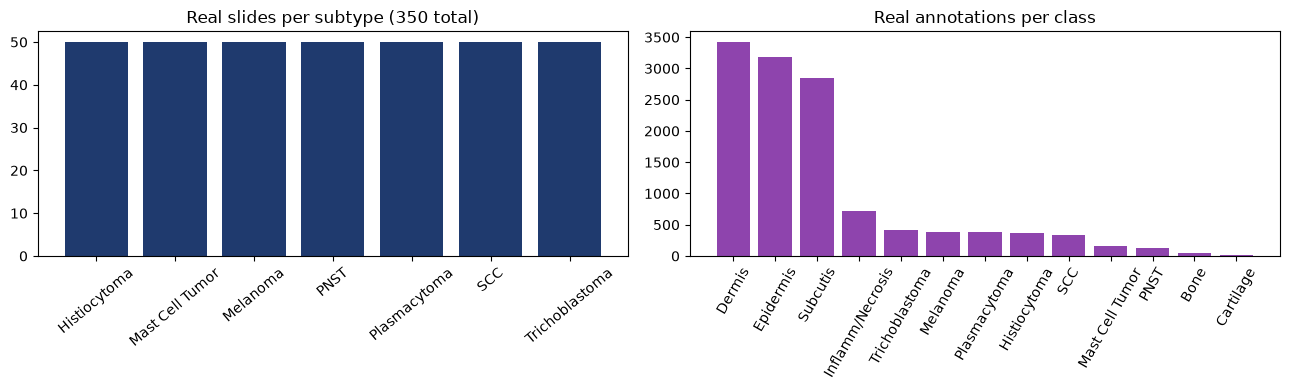

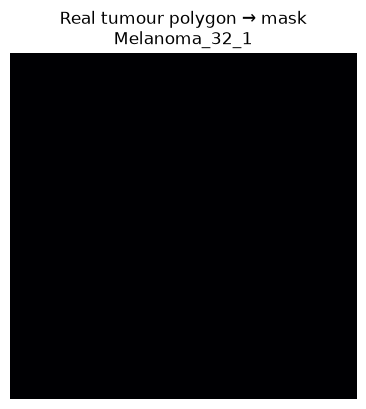

In [29]:
# REAL class distribution + a REAL tumour polygon, straight from CATCH.json
catch = cfg["catch"]
ann_file = find_annotation_file(raw, catch["coco_annotation_glob"])
if ann_file is None:
    print("Annotations not downloaded yet. Run: python -m src.data_acquisition.download_catch")
else:
    stats = coco_dataset_stats(ann_file, catch["tumour_annotation_classes"])
    print(f"REAL CATCH: {stats['n_slides']} slides, {stats['n_annotations']} polygons")
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    spp = stats["slides_per_subtype"]
    ax[0].bar(spp.keys(), spp.values(), color="#1F3A6E")
    ax[0].set_title("Real slides per subtype (350 total)"); ax[0].tick_params(axis="x", rotation=40)
    apc = stats["annotations_per_class"]
    ax[1].bar(apc.keys(), apc.values(), color="#8E44AD")
    ax[1].set_title("Real annotations per class"); ax[1].tick_params(axis="x", rotation=60)
    plt.tight_layout(); plt.show()

    per_slide = load_coco_annotations(ann_file, catch["tumour_annotation_classes"])
    sid = next(k for k in per_slide if k.startswith("Melanoma"))
    tum = [p for is_t, p in per_slide[sid] if is_t]
    c = tum[0].mean(0).astype(int); span = 4000
    mask = rasterise_tile_mask(per_slide[sid], int(c[0]-span/2), int(c[1]-span/2), span, 512)
    plt.figure(figsize=(4.5,4.5)); plt.imshow(mask, cmap="magma")
    plt.title(f"Real tumour polygon → mask\n{sid}"); plt.axis("off"); plt.show()

## 4. Weeks 1–2 — live preprocessing demo

Using the inlined code above: generate a synthetic H&E slide, run **Macenko**
normalisation, **tissue** detection, and **multi-magnification** patch extraction.

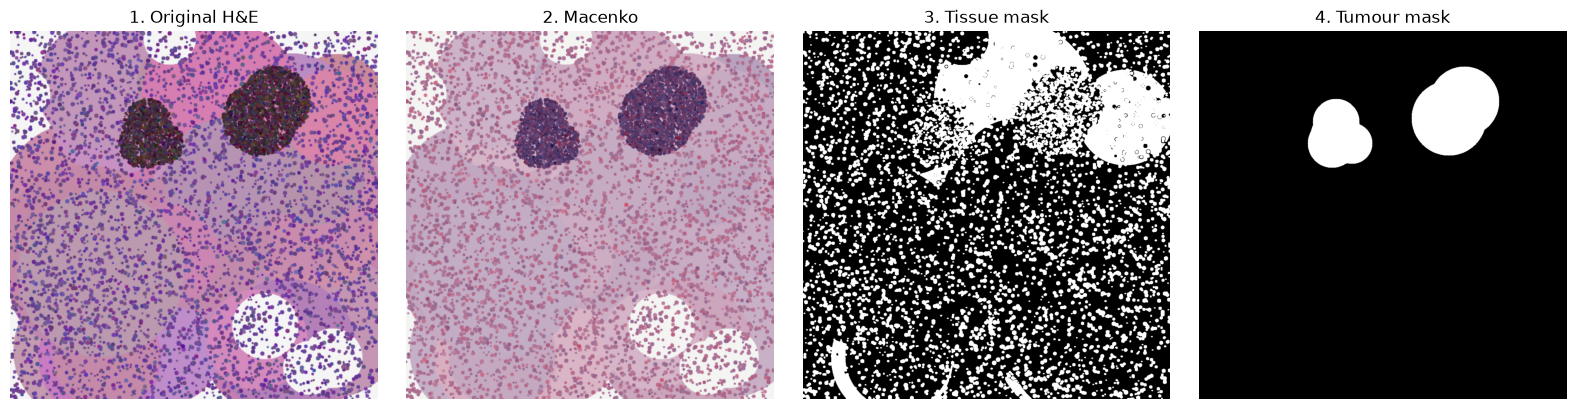

patches per magnification: {20: 3}


In [30]:
img, mask = generate_he_slide_with_mask(size=1024, n_tumours=2, seed=7)
norm = MacenkoNormalizer(**cfg["stain_normalization"]).normalize(img)
tm = tissue_mask(img)
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for a, im, t, cm in [(ax[0],img,"1. Original H&E",None),(ax[1],norm,"2. Macenko",None),
                     (ax[2],tm,"3. Tissue mask","gray"),(ax[3],mask,"4. Tumour mask","gray")]:
    a.imshow(im, cmap=cm); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

counts = {}
for (mg, y, x, p, mp) in extract_multimag_with_mask(norm, mask, [5,10,20], 20, 256, 256, 0.5, 2000, tissue_img=img):
    counts[mg] = counts.get(mg, 0) + 1
print("patches per magnification:", counts)

## 5. Weeks 3–6 — results (loaded from the saved runs)

Segmentation (3-way) and classification results from the trained runs. (Training
uses the inlined trainers above; the full commands are in §6.)

,test_dice,test_iou,test_pixel_acc,test_hausdorff,params_million,best_epoch,epochs_ran
unet_baseline,0.842,0.727,0.981,111.272,31.04,2.0,2.0
unet_resnet34,0.225,0.127,0.534,218.527,24.44,2.0,2.0
unet_attention,0.965,0.932,0.994,113.317,31.39,2.0,2.0


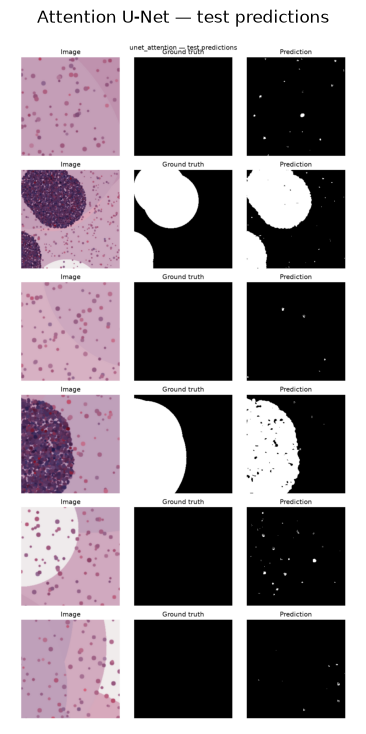

Classification classes: ['mast_cell', 'melanocytic', 'squamous_cell']
TEST  acc=1.000  macro-F1=1.000  AUC=1.0


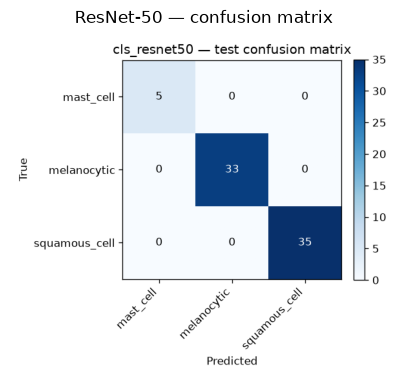

In [31]:
seg3 = load_json("week5_6_seg_comparison.json")
if seg3:
    display(pd.DataFrame(seg3).T.round(3))
show_img(FIG/"unet_attention_predictions.png", "Attention U-Net — test predictions", (9,9))

clsrep = load_json("cls_resnet50_test_report.json")
if clsrep:
    m = clsrep["test_metrics"]
    print("Classification classes:", clsrep["classes"])
    print("TEST  acc=%.3f  macro-F1=%.3f  AUC=%s" % (
        m["accuracy"], m["f1"], "n/a" if m["auc_roc"]!=m["auc_roc"] else round(m["auc_roc"],3)))
show_img(FIG/"cls_resnet50_confusion.png", "ResNet-50 — confusion matrix", (5,5))

## 6. Running on the full real CATCH dataset

The same inlined code runs on the real slides. Place the `.svs` files under
`data/raw/<Subtype>/` (or flat — labels come from the filename prefix, e.g.
`MCT_15_1.svs`), then:

```bash
python -m src.data_acquisition.download_catch              # annotations + folders
python scripts/prepare_segmentation_data.py  --input data/raw
python scripts/train_unet.py --arch attention
python scripts/prepare_classification_data.py --input data/raw
python scripts/train_classifier.py --arch resnet50 --epochs 20
```

> Needs ~600 GB free + OpenSlide binaries. The 522 GB of WSIs download via the
> Aspera plugin from the TCIA collection page (DOI 10.7937/TCIA.2M93-FX66).

## 7. Summary

**Done (W1–6):** preprocessing · baseline + ResNet-34 + **Attention** U-Net
segmentation · **ResNet-50** subtype classification · real CATCH annotations
integrated · **all source code now lives in this notebook**.

**Next:** EfficientNet-B3 comparison · real-slide run on a larger disk · evaluation
(5-fold CV, McNemar's test, Grad-CAM).